# Lab Exam 2, AI for Communication and Marketing

*Beatrice Camera, 535313*

Customer retention is one of the highest-leverage problems in e-commerce marketing. Acquiring a new customer costs significantly more than retaining an existing one, yet most marketing budgets remain acquisition-heavy. The objective of this analysis is to reverse that logic: to identify, before they leave, which customers are at risk of churning, and to translate that prediction into a concrete, actionable communication strategy.

**Business context.** As a Data Scientist embedded in the Marketing department of a leading e-commerce platform, the task is to build a predictive churn model from customer-level data.

The analytical process follows a progressive logic. It begins with a data audit to ensure the dataset is clean and consistent enough to train a reliable model. It then moves to exploratory analysis, where the goal is to identify the behavioural patterns that differentiate churners from retained customers, with particular focus on tenure, complaints, purchasing behaviour, and customer recency. These findings directly inform the modelling phase, where three classification algorithms are trained, compared, and evaluated against the asymmetric cost structure of churn prediction. Finally, the model's outputs are translated into targeted marketing recommendations.

The analysis is organised as follows:

- **Section 1, Data Audit & Quality**: validation, cleaning, and encoding of the dataset
- **Section 2, Exploratory Data Analysis**: identification of churn drivers and behavioral patterns
- **Section 3, Modeling & Evaluation**: propensity model training, comparison, and performance assessment
- **Section 4, Communication Strategy**: translation of model findings into actionable marketing decisions
- **Section 5, From Model to Action**: operational deployment, trigger-based automation, and model monitoring
- **Section 6, Conclusion**

The overall objective is not only to predict which customers will churn, but to understand the mechanisms behind churn and translate those insights into targeted, measurable, and commercially actionable interventions.

In [3]:
import subprocess
import sys

subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost', 'missingno', 'shap', '--quiet'])
print('Dependencies installed.')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import missingno as msno
import shap
import warnings
from scipy.stats import zscore

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, recall_score, precision_score, accuracy_score,
    roc_curve, auc, roc_auc_score, 
)
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

NAVY_DARK    = '#1B2A4A'   
NAVY_MID     = '#1F4E8C'   
NAVY_LIGHT   = '#4B6FA5'  
NAVY_PALE    = '#8AADD4'   
ACCENT_RED   = '#C0392B'   # For churn / risk signals
ACCENT_GREEN = '#1A6B4A'   # For retained / positive signals
PALETTE_SEQ  = [NAVY_DARK, NAVY_MID, NAVY_LIGHT, NAVY_PALE]

sns.set_theme(style='whitegrid', font_scale=1.0)
plt.rcParams.update({
    'figure.dpi'         : 110,
    'axes.titlesize'     : 12,
    'axes.labelsize'     : 10,
    'xtick.labelsize'    : 9,
    'ytick.labelsize'    : 9,
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
})

RANDOM_STATE = 42
print('Setup complete.')

Dependencies installed.
Setup complete.


/opt/homebrew/Caskroom/miniforge/base/envs/ai4cm-env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
df_raw = pd.read_excel(
    'https://raw.githubusercontent.com/BeatriceCamera/AI4CM_projects/main/data.xlsx'
)

print(f'Dataset shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
df_raw.head()

Dataset shape: 5,630 rows × 20 columns


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001.00,1,4.00,Mobile Phone,3,6.00,Debit Card,Female,3.00,3,Laptop & Accessory,2,Single,9,1,11.00,1.00,1.00,5.00,159.93
1,50002.00,1,NaN,Phone,1,8.00,UPI,Male,3.00,4,Mobile,3,Single,7,1,15.00,0.00,1.00,0.00,120.90
2,50003.00,1,NaN,Phone,1,30.00,Debit Card,Male,2.00,4,Mobile,3,Single,6,1,14.00,0.00,1.00,3.00,120.28
3,50004.00,1,0.00,Phone,3,15.00,Debit Card,Male,2.00,4,Laptop & Accessory,5,Single,8,0,23.00,0.00,1.00,3.00,134.07
4,50005.00,1,0.00,Phone,1,12.00,CC,Male,NaN,3,Mobile,5,Single,3,0,11.00,1.00,1.00,3.00,129.60


The dataset contains 5,630 customer records and 20 variables. Each row represents a unique customer profile, combining demographic attributes (gender, marital status, city tier), engagement signals (hours on app, devices registered, preferred login device), satisfaction indicators (satisfaction score, complaints filed), and transactional history (tenure, order count, cashback amount). The target variable `Churn` is a binary flag indicating whether the customer has already left the platform.

This combination of *who* customers are, *how* they engage, and *whether* they are showing early disengagement signals makes the dataset structurally suited for predictive retention modelling.

Two structural observations are immediately relevant. First, `CustomerID` is stored as a float rather than an integer, likely due to missing values being read as NaN, which forces float casting. This column will be dropped before modelling, as it is an identifier with no predictive value. Second, several columns have missing values that require treatment before any analysis or encoding can proceed.

## 1. Data Audit and Quality

Before any transformation, encoding, or modelling, the dataset must be assessed for integrity. In a churn prediction context, data quality issues carry a specific risk: if the features used to train the model contain systematic errors, like impossible values, inconsistent labels, or biased missingness, the model will learn from noise rather than signal. A high-performing model on corrupted data is not a good model; it is a well-fitted approximation of the wrong problem.

The audit proceeds in four stages:
1. **Structural overview:** duplicates, ID consistency
2. **Missing value analysis:** extent, pattern, and imputation strategy
3. **Outlier and consistency checks:** domain-rule violations and extreme values
4. **Categorical harmonisation and encoding:** label consolidation and ML-compatible representation

Each cleaning decision is documented with a rationale. The goal is not a perfectly pristine dataset, but a reliable one.

### **1.1 Duplicates**

In [5]:
# Duplicates and ID integrity
full_dups = df_raw.duplicated().sum()
id_dups   = df_raw.dropna(subset=['CustomerID']).duplicated(subset='CustomerID').sum()

print(f'Full duplicate rows   : {full_dups}')
print(f'Duplicate CustomerIDs : {id_dups}')

Full duplicate rows   : 0
Duplicate CustomerIDs : 0


### **1.2 Missing Value Analysis**

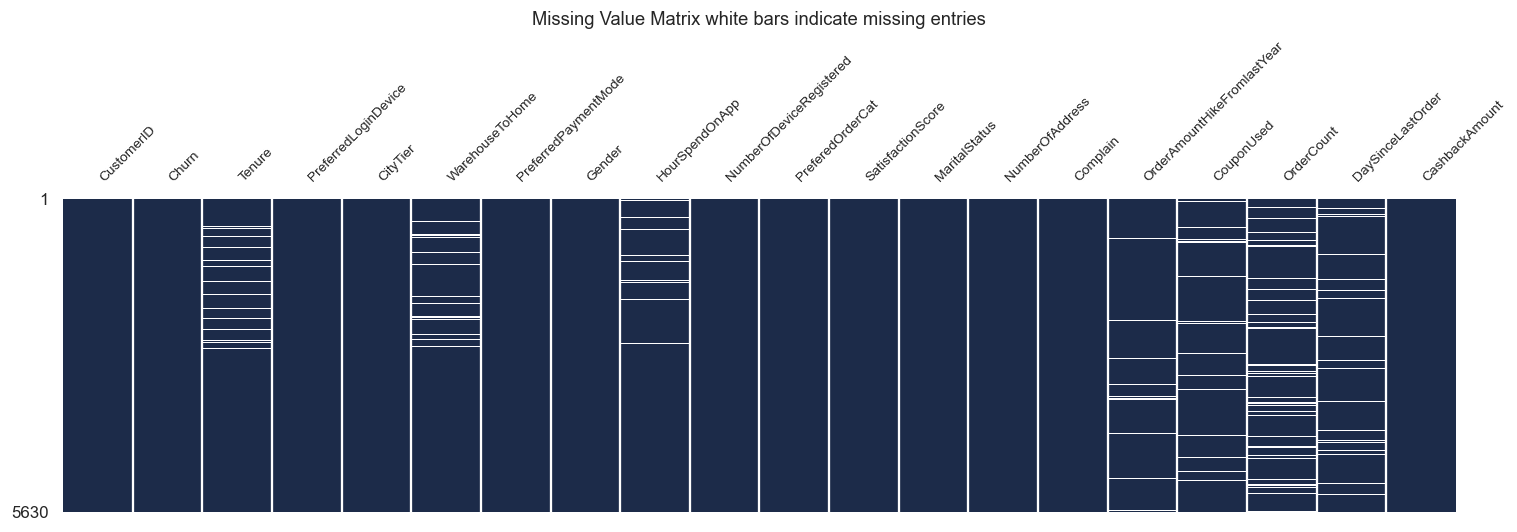

In [6]:
# Missingno matrix: each row is an observation; white = missing
fig, ax = plt.subplots(figsize=(14, 5))
msno.matrix(df_raw, ax=ax, sparkline=False, fontsize=9,
            color=(0.11, 0.17, 0.29))  
ax.set_title('Missing Value Matrix white bars indicate missing entries',
             fontsize=12, pad=10)
plt.tight_layout()
plt.show()

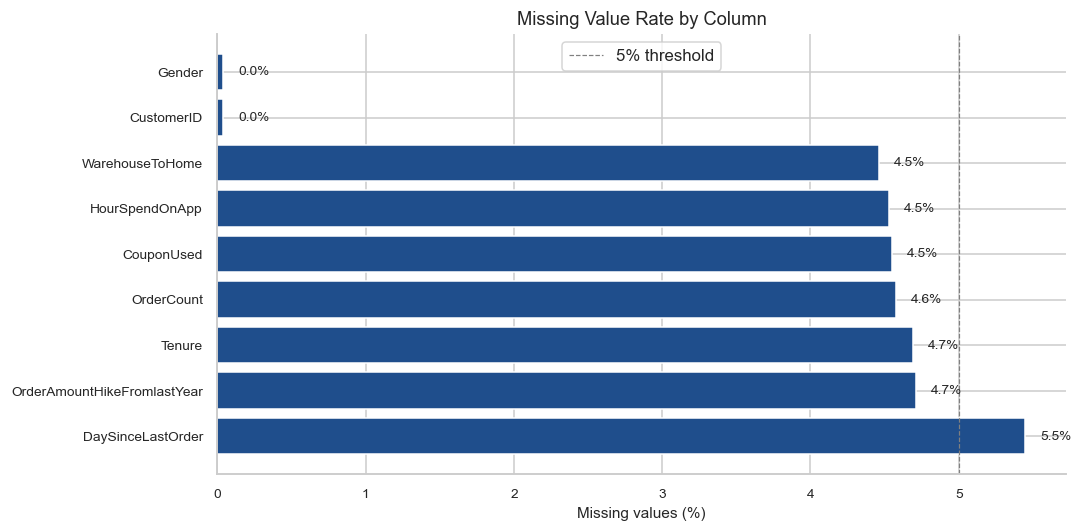

                             Missing Count  Missing %
DaySinceLastOrder                      307       5.45
OrderAmountHikeFromlastYear            265       4.71
Tenure                                 264       4.69
OrderCount                             258       4.58
CouponUsed                             256       4.55
HourSpendOnApp                         255       4.53
WarehouseToHome                        251       4.46
CustomerID                               2       0.04
Gender                                   2       0.04


In [7]:
# Focused table: columns with missing values
missing = df_raw.isnull().sum()
missing_cols = missing[missing > 0].sort_values(ascending=False)
missing_report = pd.DataFrame({
    'Missing Count': missing_cols,
    'Missing %'    : (missing_cols / len(df_raw) * 100).round(2)
})

# Visual
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(missing_report.index, missing_report['Missing %'],
               color=NAVY_MID, edgecolor='white')
ax.axvline(5, color='grey', linestyle='--', linewidth=0.8, label='5% threshold')
for bar, pct in zip(bars, missing_report['Missing %']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Missing values (%)')
ax.set_title('Missing Value Rate by Column', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

print(missing_report)

Missingness is present in 9 of 20 columns, ranging from 0.04% (`CustomerID`, `Gender`) to 5.45% (`DaySinceLastOrder`). All missing rates remain relatively low (<6%). Visual inspection of the missingness pattern does not reveal obvious clustering or systematic structures, suggesting that missing values are broadly dispersed throughout the dataset.

Two imputation strategies are applied:

| Strategy | Applied to | Rationale |
|---|---|---|
| **Median imputation** | Numerical Columns | Robust to skewed distributions and outliers; preserves central tendency without being influenced by extreme values |
| **Mode imputation** | `Gender` | Only 2 missing values; mode is the most conservative choice for a binary categorical |

`CustomerID` is removed because it is an identifier rather than a predictive feature. 

Row deletion is not adopted. Although missingness is relatively low, removing all incomplete observations would eliminate more than 300 customers and unnecessarily reduce the available information. Imputation preserves sample size while maintaining variables that are expected to be important predictors of churn, such as `DaySinceLastOrder` and `Tenure`.

In [8]:
df = df_raw.copy()

# Numerical columns: median imputation
num_cols_with_missing = [
    'Tenure', 'WarehouseToHome', 'HourSpendOnApp',
    'OrderAmountHikeFromlastYear', 'CouponUsed',
    'OrderCount', 'DaySinceLastOrder'
]

medians = df[num_cols_with_missing].median()
df[num_cols_with_missing] = df[num_cols_with_missing].fillna(medians)

# Gender: mode imputation (only 2 missing)
gender_mode = df['Gender'].mode()[0]
df['Gender'] = df['Gender'].fillna(gender_mode)

# CustomerID: drop, identifier with no predictive value
df = df.drop(columns=['CustomerID'])

remaining_missing = df.isnull().sum().sum()
print(f'Missing values after imputation: {remaining_missing}')
print(f'Columns: {df.shape[1]} (CustomerID dropped)')

# Imputation summary
imp_summary = pd.DataFrame({
    'Column'         : num_cols_with_missing + ['Gender'],
    'Strategy'       : ['Median'] * len(num_cols_with_missing) + ['Mode'],
    'Value used'     : [round(medians[c], 2) for c in num_cols_with_missing] + [gender_mode],
    'N imputed'      : [missing_cols[c] if c in missing_cols else 2
                        for c in num_cols_with_missing] + [2]
})
print('\nImputation summary:')
imp_summary

Missing values after imputation: 0
Columns: 19 (CustomerID dropped)

Imputation summary:


,Column,Strategy,Value used,N imputed
0,Tenure,Median,9.00,264
1,WarehouseToHome,Median,14.00,251
2,HourSpendOnApp,Median,3.00,255
3,OrderAmountHikeFromlastYear,Median,15.00,265
4,CouponUsed,Median,1.00,256
5,OrderCount,Median,2.00,258
6,DaySinceLastOrder,Median,3.00,307
7,Gender,Mode,Male,2


### **1.3 Outlier Detection and Domain Consistency**

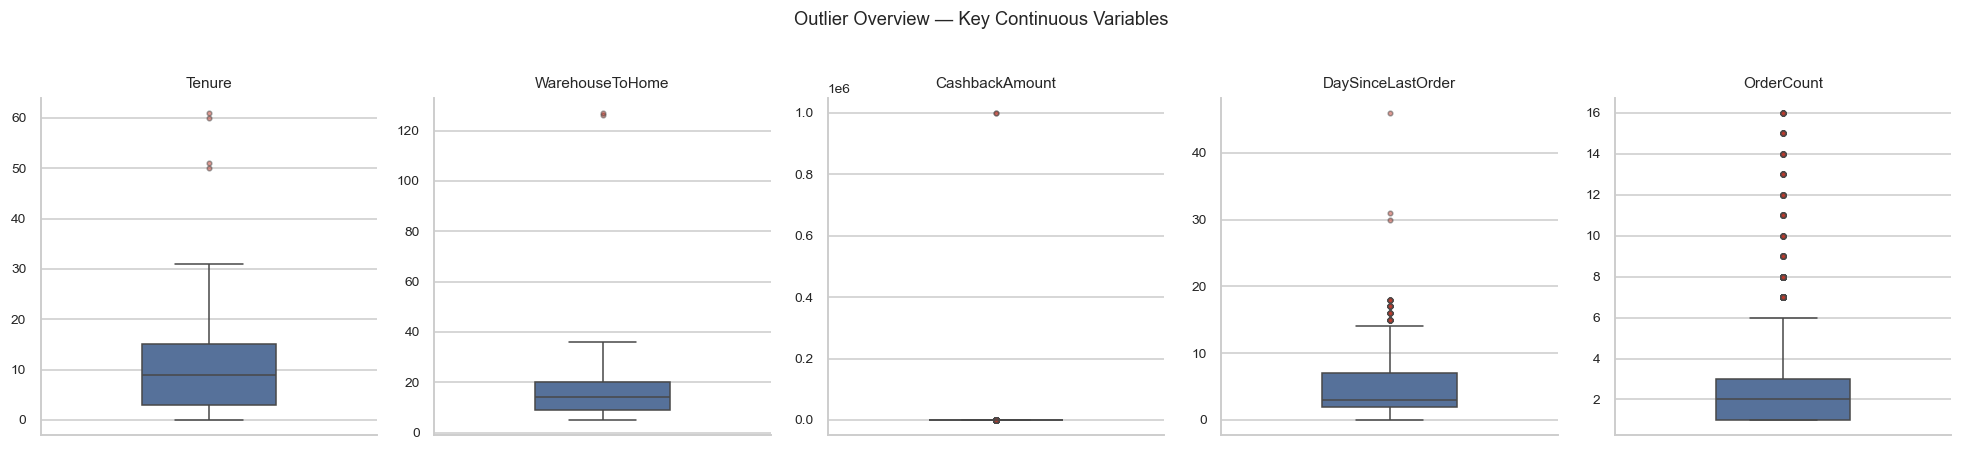

In [9]:
# Overview boxplots for key numerical variables
outlier_vars = ['Tenure', 'WarehouseToHome', 'CashbackAmount',
                'DaySinceLastOrder', 'OrderCount']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, outlier_vars):
    sns.boxplot(y=df[col], ax=ax, color=NAVY_LIGHT, width=0.4,
                flierprops=dict(marker='o', markerfacecolor=ACCENT_RED,
                                markersize=3, alpha=0.5))
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('')

fig.suptitle('Outlier Overview — Key Continuous Variables', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [10]:
# Domain-rule checks

# WarehouseToHome
wh_extreme = df[df['WarehouseToHome'] > 100]
print(f'WarehouseToHome > 100 km : {len(wh_extreme)} rows')
print(wh_extreme[['WarehouseToHome', 'Churn', 'Tenure']].to_string())

# Tenure
print(f'\nTenure range: {df["Tenure"].min():.0f} – {df["Tenure"].max():.0f} months')
print('No implausible values.')

# CashbackAmount
cb_extreme = df[df['CashbackAmount'] > 1000]
print(f'\nCashbackAmount > 1,000 : {len(cb_extreme)} rows')
print(cb_extreme[['CashbackAmount', 'Churn', 'Tenure']].to_string())
print(f'99th percentile of CashbackAmount: {df["CashbackAmount"].quantile(0.99):.2f}')

# OrderCount
print(f'\nOrderCount range: {df["OrderCount"].min():.0f} – {df["OrderCount"].max():.0f}')
print('High values are uncommon but plausible for highly engaged customers.')

# DaySinceLastOrder
print(f'\nDaySinceLastOrder range: {df["DaySinceLastOrder"].min():.0f} – {df["DaySinceLastOrder"].max():.0f} days')
print('Higher values indicate inactivity and are expected in a churn dataset.')

WarehouseToHome > 100 km : 2 rows
      WarehouseToHome  Churn  Tenure
1309           126.00      0   25.00
4124           127.00      0   26.00

Tenure range: 0 – 61 months
No implausible values.

CashbackAmount > 1,000 : 2 rows
      CashbackAmount  Churn  Tenure
590        999999.00      0    6.00
5518       999999.00      0    5.00
99th percentile of CashbackAmount: 319.02

OrderCount range: 1 – 16
High values are uncommon but plausible for highly engaged customers.

DaySinceLastOrder range: 0 – 46 days
Higher values indicate inactivity and are expected in a churn dataset.


**WarehouseToHome:** Two observations show distances above 100 km (126–127 km), far outside the distribution of the remaining customers. Given their extreme rarity (2 records out of 5,630) and their large separation from the bulk of the data, these values were treated as likely data-quality anomalies and removed.

**Tenure:** Range of 0 to 61 months is fully plausible. A tenure of 0 represents a new customer with less than one month on the platform. No removal or capping is needed.

**CashbackAmount:** Two records show a value of 999,999, against a 99th percentile of approximately 319. The magnitude of these values strongly suggests a placeholder for missing or erroneous cashback records in transactional systems. The gap between the 99th percentile and the maximum is so extreme that no business scenario justifies it. Rather than removing the observations, CashbackAmount was winsorised at the 99th percentile (€319.02), preserving the remaining customer information while preventing extreme values from distorting scaling procedures and distance-based algorithms.

**OrderCount:** The maximum observed value is 16 orders. Although this appears as a statistical outlier in the boxplot, it remains entirely plausible from a business perspective. Highly engaged customers may legitimately place substantially more orders than the average customer. Consequently, these observations were retained.

**DaySinceLastOrder:** The maximum observed value is 46 days. While this value falls outside the upper whisker of the distribution, it is fully consistent with customer inactivity behaviour and is directly related to churn risk. Since the variable captures meaningful behavioural variation rather than data-quality issues, no treatment was applied.

In [11]:
rows_before = len(df)

# Remove implausible WarehouseToHome values
df = df[df['WarehouseToHome'] <= 100].copy()
print(f'Rows removed (WarehouseToHome > 100): {rows_before - len(df)}')

# Cap CashbackAmount at 99th percentile
cb_cap = df['CashbackAmount'].quantile(0.99)
n_capped = (df['CashbackAmount'] > cb_cap).sum()
df['CashbackAmount'] = df['CashbackAmount'].clip(upper=cb_cap)
print(f'CashbackAmount capped at €{cb_cap:.2f} ({n_capped} values affected)')
print(f'\nFinal dataset: {len(df):,} rows')

Rows removed (WarehouseToHome > 100): 2
CashbackAmount capped at €319.02 (57 values affected)

Final dataset: 5,628 rows


### **1.4 Categorical Harmonisation and Encoding**

Before encoding, categorical variables require inspection for label inconsistencies, meaning different strings representing the same semantic category. This step is prior to and independent of encoding: it ensures the model does not learn spurious distinctions from what is effectively the same category.

Two variables contain duplicate labels:

In [12]:
# Inspect raw categorical distributions before harmonisation
cat_cols = ['PreferredLoginDevice', 'PreferredPaymentMode',
            'PreferedOrderCat', 'MaritalStatus', 'Gender']

for col in cat_cols:
    print(f'{col}:')
    print(df[col].value_counts().to_string())
    print()

PreferredLoginDevice:
PreferredLoginDevice
Mobile Phone    2763
Computer        1630
Phone           1230
N.A.               5

PreferredPaymentMode:
PreferredPaymentMode
Debit Card          2312
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149

PreferedOrderCat:
PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1270
Fashion                826
Mobile                 808
Grocery                410
Others                 264

MaritalStatus:
MaritalStatus
Married     2982
Single      1795
Divorced     848
Widow          3

Gender:
Gender
Male      3383
Female    2245



Three inconsistencies are identified:

| Variable | Duplicate Labels | Consolidation |
|---|---|---|
| `PreferredPaymentMode` | `'CC'` and `'Credit Card'` are the same payment type | Merge both into `'Credit Card'` |
| `PreferredPaymentMode` | `'COD'` and `'Cash on Delivery'` are the same payment type | Merge both into `'Cash on Delivery'` |
| `PreferedOrderCat` | `'Mobile'` and `'Mobile Phone'` refer to the same product category | Merge both into `'Mobile Phone'` |
| `PreferredLoginDevice` | `'N.A.'` is not a device category but a missing value encoded as string | Reassign to the mode (`'Mobile Phone'`) |

These inconsistencies would artificially fragment identical customer groups, causing the same behaviour to be represented by multiple categories and increasing unnecessary feature sparsity after encoding.

In [13]:
# Label harmonisation

# PreferredPaymentMode: merge duplicate labels
payment_map = {
    'CC'              : 'Credit Card',
    'COD'             : 'Cash on Delivery',
    'Debit Card'      : 'Debit Card',
    'Credit Card'     : 'Credit Card',
    'E wallet'        : 'E wallet',
    'UPI'             : 'UPI',
    'Cash on Delivery': 'Cash on Delivery',
}
df['PreferredPaymentMode'] = df['PreferredPaymentMode'].map(payment_map)

# PreferedOrderCat: merge 'Mobile' into 'Mobile Phone'
df['PreferedOrderCat'] = df['PreferedOrderCat'].replace({'Mobile': 'Mobile Phone'})

# PreferredLoginDevice: reassign 'N.A.' to mode
login_mode = df[df['PreferredLoginDevice'] != 'N.A.']['PreferredLoginDevice'].mode()[0]
df['PreferredLoginDevice'] = df['PreferredLoginDevice'].replace({'N.A.': login_mode})

print('Harmonised PreferredPaymentMode:')
print(df['PreferredPaymentMode'].value_counts())
print('\nHarmonised PreferedOrderCat:')
print(df['PreferedOrderCat'].value_counts())
print('\nHarmonised PreferredLoginDevice:')
print(df['PreferredLoginDevice'].value_counts())

Harmonised PreferredPaymentMode:
PreferredPaymentMode
Debit Card          2312
Credit Card         1774
E wallet             614
Cash on Delivery     514
UPI                  414
Name: count, dtype: int64

Harmonised PreferedOrderCat:
PreferedOrderCat
Mobile Phone          2078
Laptop & Accessory    2050
Fashion                826
Grocery                410
Others                 264
Name: count, dtype: int64

Harmonised PreferredLoginDevice:
PreferredLoginDevice
Mobile Phone    2768
Computer        1630
Phone           1230
Name: count, dtype: int64


After harmonisation, categorical variables are encoded for machine learning compatibility.

Two encoding strategies are used:

| Strategy | Applied to | Rationale |
|---|---|---|
| **Label Encoding** | `Gender` | Binary variable; a 0/1 representation is sufficient and does not introduce an artificial order among multiple categories |
| **One-Hot Encoding** | `MaritalStatus`, `PreferredLoginDevice`, `PreferredPaymentMode`, `PreferedOrderCat` | Nominal variables with no natural order; one-hot encoding prevents the model from learning spurious numerical relationships between categories |

`drop_first=True` is applied to one-hot encoding to avoid perfect multicollinearity, which is particularly important for Logistic Regression.

In [14]:
# Binary encoding for Gender
df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})

print("Gender encoding:")
print({0: 'Female', 1: 'Male'})

# One-hot encoding for nominal categorical variables
ohe_cols = [
    'MaritalStatus',
    'PreferredLoginDevice',
    'PreferredPaymentMode',
    'PreferedOrderCat'
]

df_encoded = pd.get_dummies(df, columns=ohe_cols, drop_first=True, dtype=int)

print(f'\nFeature matrix after encoding: {df_encoded.shape[0]:,} rows × {df_encoded.shape[1]} columns')
print(f'New OHE columns: {df_encoded.shape[1] - df.shape[1] + len(ohe_cols)}')
print(f'All dtypes numeric: {df_encoded.dtypes.apply(lambda x: pd.api.types.is_numeric_dtype(x)).all()}')

Gender encoding:
{0: 'Female', 1: 'Male'}

Feature matrix after encoding: 5,628 rows × 28 columns
New OHE columns: 13
All dtypes numeric: True


The final encoded dataset contains only numerical variables and is therefore compatible with machine learning models. `Gender` is represented as a binary feature, while all multi-category nominal variables are expanded through one-hot encoding. This avoids imposing an artificial ranking on categories such as marital status, payment method, login device, or order category.

### **1.5 Cleaning Summary**

The table below documents every decision made in this phase. The cleaned and encoded dataset is the single source of truth for all downstream analysis and modelling.

In [15]:
# Cleaning summary

rows_before = df_raw.shape[0]
rows_after  = df.shape[0]

missing_before = df_raw.isnull().sum().sum()
missing_after  = df.isnull().sum().sum()

full_dups_before = df_raw.duplicated().sum()
id_dups_before   = df_raw.dropna(subset=['CustomerID']).duplicated(subset='CustomerID').sum()

wh_removed = (df_raw['WarehouseToHome'] > 100).sum()
cb_sentinel = (df_raw['CashbackAmount'] == 999999).sum()

pay_cats_before = df_raw['PreferredPaymentMode'].nunique()
pay_cats_after  = df['PreferredPaymentMode'].nunique()

ord_cats_before = df_raw['PreferedOrderCat'].nunique()
ord_cats_after  = df['PreferedOrderCat'].nunique()

device_cats_before = df_raw['PreferredLoginDevice'].nunique()
device_cats_after  = df['PreferredLoginDevice'].nunique()

ohe_created = df_encoded.shape[1] - (df.shape[1] - len(ohe_cols))
net_feature_increase = df_encoded.shape[1] - df.shape[1]

summary = pd.DataFrame({
    'Metric': [
        'Total rows',
        'Columns',
        'Missing values',
        'Full duplicate rows',
        'Duplicate CustomerIDs',
        'WarehouseToHome > 100 km',
        'CashbackAmount sentinel (999,999)',
        'CashbackAmount values capped at P99',
        'PaymentMode categories',
        'OrderCategory categories',
        'LoginDevice categories',
        'Encoded features'
    ],
    'Before cleaning': [
        rows_before,
        df_raw.shape[1],
        missing_before,
        full_dups_before,
        id_dups_before,
        'Present',
        cb_sentinel,
        'Not applied',
        pay_cats_before,
        ord_cats_before,
        device_cats_before,
        'None'
    ],
    'After cleaning': [
        rows_after,
        df_encoded.shape[1],
        missing_after,
        '0 original full duplicates',
        'CustomerID dropped',
        f'Removed: {wh_removed}',
        'Corrected through P99 capping',
        f'{n_capped} values capped',
        pay_cats_after,
        ord_cats_after,
        device_cats_after,
        f'{ohe_created} OHE columns created; net +{net_feature_increase} columns; Gender label-encoded'
    ]
})

summary.set_index('Metric')

,Before cleaning,After cleaning
Metric,,
Total rows,5630,5628
Columns,20,28
Missing values,1860,0
Full duplicate rows,0,0 original full duplicates
Duplicate CustomerIDs,0,CustomerID dropped
WarehouseToHome > 100 km,Present,Removed: 2
"CashbackAmount sentinel (999,999)",2,Corrected through P99 capping
CashbackAmount values capped at P99,Not applied,57 values capped
PaymentMode categories,7,5


## 2. Exploratory Data Analysis (EDA)

The cleaning phase established a reliable dataset: missing values were imputed where no strong missingness structure was observed, domain violations were corrected, and categorical variables were encoded for ML compatibility. The EDA now shifts the question from *'is this data trustworthy?'* to *'what does this data reveal about churn?'*

Three lines of inquiry structure the analysis:
1. **Satisfaction and complaints:** do dissatisfied customers churn at a meaningfully higher rate, and does the combination of low satisfaction *and* a complaint create a compounding risk?
2. **Tenure and recency:** does churn concentrate among new customers, long-tenured ones, or those who have been inactive recently?
3. **Class balance:** is the dataset skewed toward churners or non-churners, and what does that imply for modelling?

These three questions map directly to the business decisions downstream. If satisfaction drives churn, the intervention is service improvement. If recency does, the intervention is reactivation. If the class is severely imbalanced, the model must be calibrated accordingly.

In [16]:
# Working copy pre-encoding for EDA (human-readable labels)
df_eda = df.copy()
df_eda['Churn_Label'] = df_eda['Churn'].map({0: 'Retained', 1: 'Churned'})

### **2.1 Class Balance**
Before examining individual predictors, the distribution of the target variable must be assessed. In a churn dataset, class balance has direct consequences for how the model should be trained and evaluated. A churn label is inherently rare: most customers, at any given point in time, have not left. This structural asymmetry means that a model trained without adjustment will learn to predict "retained" for virtually everyone, achieving high accuracy while missing the customers it was built to find. 

Churn distribution:
       Count  Percentage (%)
Churn                       
0       4680           83.20
1        948           16.80

Class ratio (non-churner : churner) = 4.9 : 1
scale_pos_weight for XGBoost/RF     = 4.94


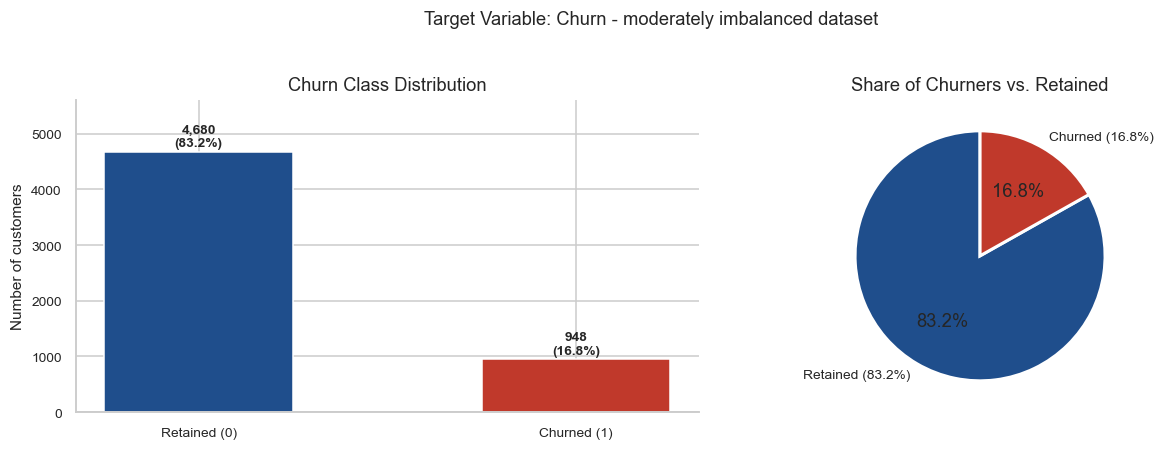

In [17]:
churn_counts = df_eda['Churn'].value_counts().sort_index()
churn_pct    = (churn_counts / len(df_eda) * 100).round(1)

print('Churn distribution:')
print(pd.DataFrame({'Count': churn_counts,
                    'Percentage (%)': churn_pct}))

scale_pos_weight = churn_counts[0] / churn_counts[1]
print(f'\nClass ratio (non-churner : churner) = {scale_pos_weight:.1f} : 1')
print(f'scale_pos_weight for XGBoost/RF     = {scale_pos_weight:.2f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = [NAVY_MID, ACCENT_RED]
bars = axes[0].bar(['Retained (0)', 'Churned (1)'],
                   churn_counts.values,
                   color=colors, edgecolor='white', width=0.5)
for bar, pct in zip(bars, churn_pct.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 40,
                 f'{int(bar.get_height()):,}\n({pct}%)',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_title('Churn Class Distribution')
axes[0].set_ylabel('Number of customers')
axes[0].set_ylim(0, churn_counts.max() * 1.2)

# Pie
axes[1].pie(churn_counts.values,
            labels=[f'Retained ({churn_pct[0]}%)', f'Churned ({churn_pct[1]}%)'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Share of Churners vs. Retained')

fig.suptitle('Target Variable: Churn - moderately imbalanced dataset',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

The dataset is moderately imbalanced: 83.2% of customers are retained and 16.8% have churned, corresponding to approximately one churner for every five retained customers.

While the imbalance is not severe enough to require resampling techniques such as SMOTE, it is substantial enough to bias standard accuracy metrics. As a result, model evaluation will focus on Recall, Precision, F1-score and ROC-AUC rather than accuracy alone.

The class imbalance will be addressed during modelling through class weighting (`class_weight='balanced'` for Logistic Regression and Random Forest) and `scale_pos_weight` for XGBoost, which instructs the model to penalise missed churners more heavily than false alarms. The asymmetry is business-justified: the cost of missing a churner (lost customer lifetime value) is structurally higher than the cost of flagging a retained customer for a retention offer.

### **2.2 Satisfaction, Complaints, and Churn**
Satisfaction scores and complaint records are two customer-experience indicators available in the dataset. While both relate to the customer's perception of the service, they capture different dimensions of the relationship. `SatisfactionScore` is a self-reported evaluation, whereas `Complain` records an observable behavioural action taken by the customer.

The objective of this analysis is therefore twofold. First, to assess whether satisfaction levels are associated with churn risk. Second, to determine whether complaint behaviour provides additional predictive information beyond satisfaction alone. The analysis proceeds in three steps: churn rate by `SatisfactionScore`, churn rate by `complaint` status, and a combined heatmap examining the interaction between the two variables.

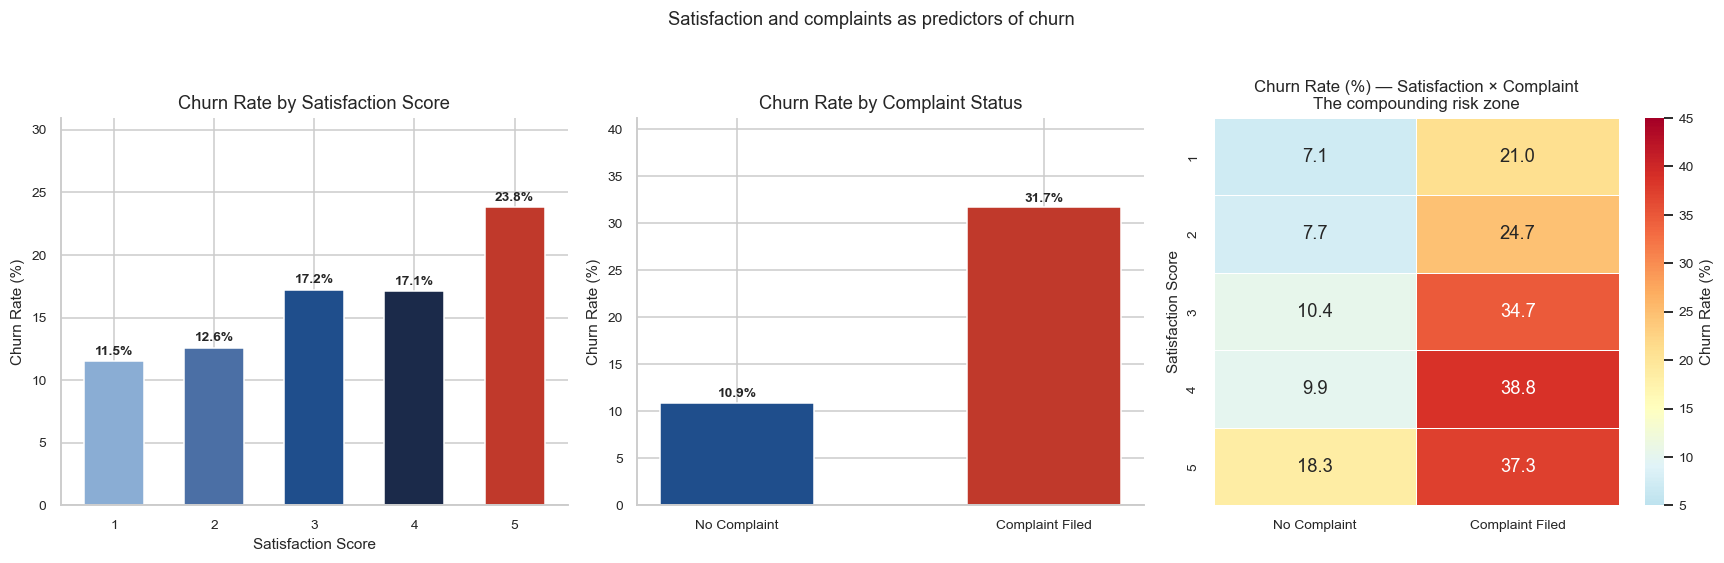

In [18]:
# Churn rate by SatisfactionScore
sat_churn = df_eda.groupby('SatisfactionScore')['Churn'].mean().mul(100).round(1)

# Churn rate by Complain
comp_churn = df_eda.groupby('Complain')['Churn'].mean().mul(100).round(1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Satisfaction score vs churn rate
bars = axes[0].bar(sat_churn.index, sat_churn.values,
                   color=[NAVY_PALE, NAVY_LIGHT, NAVY_MID, NAVY_DARK, ACCENT_RED],
                   edgecolor='white', width=0.6)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}%',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_title('Churn Rate by Satisfaction Score')
axes[0].set_xlabel('Satisfaction Score')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, sat_churn.max() * 1.3)

# Complain vs churn rate
bars2 = axes[1].bar(['No Complaint', 'Complaint Filed'],
                    comp_churn.values,
                    color=[NAVY_MID, ACCENT_RED],
                    edgecolor='white', width=0.5)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}%',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_title('Churn Rate by Complaint Status')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, comp_churn.max() * 1.3)

# Combined heatmap: SatisfactionScore × Complain
heatmap_data = (
    df_eda.groupby(['SatisfactionScore', 'Complain'])['Churn']
    .mean()
    .mul(100)
    .round(1)
    .unstack()
)
heatmap_data.columns = ['No Complaint', 'Complaint Filed']

sns.heatmap(heatmap_data, annot=True, fmt='.1f',
            cmap='RdYlBu_r', center=15, vmin=5, vmax=45,
            linewidths=0.5, linecolor='white',
            ax=axes[2],
            cbar_kws={'label': 'Churn Rate (%)'})
axes[2].set_title('Churn Rate (%) — Satisfaction × Complaint\n'
                  'The compounding risk zone', fontsize=11)
axes[2].set_xlabel('')
axes[2].set_ylabel('Satisfaction Score')

fig.suptitle('Satisfaction and complaints as predictors of churn',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

The three panels reveal that complaints are substantially more informative than satisfaction scores when explaining churn behaviour.

**Satisfaction score alone provides limited predictive power.** Churn increases from 11.5% for customers with a score of 1 to 23.8% for customers with a score of 5. However, the relationship is not accompanied by equally strong differences in behavioural variables such as tenure, order frequency, or recency. SatisfactionScore therefore appears associated with churn, but it does not provide a clear behavioural explanation on its own.

**Complaints are a much stronger signal.** Customers who filed a complaint exhibit a churn rate of 31.7%, compared with only 10.9% among customers who did not. This represents almost a threefold increase in churn risk. Unlike satisfaction scores, complaints reflect a concrete customer action and therefore capture active dissatisfaction rather than stated perception.

**The interaction highlights the highest-risk customers.** The heatmap shows that complaint status consistently increases churn risk across all satisfaction levels. Several complaint groups exceed 35% churn, while equivalent non-complaint groups remain below 20%. This suggests that complaint behaviour carries predictive information beyond satisfaction alone.

Therefore, customers who file complaints should be prioritised for retention and service-recovery actions, as they represent the segment most likely to disengage from the platform.

### **2.3 Tenure and Recency as Churn Drivers**
Tenure and recency capture two different dimensions of customer engagement. `Tenure` measures the maturity of the customer relationship, while `DaySinceLastOrder` captures recent activity. Both variables are commonly associated with churn risk, but their relative importance is an empirical question. The objective of this section is therefore to determine whether churn is concentrated among recently acquired customers, inactive customers, or both.

The analysis first examines the distribution of Tenure and `DaySinceLastOrder` across churned and retained customers, then quantifies churn rates across tenure groups and finally evaluates whether complaints amplify churn risk at different stages of the customer lifecycle.

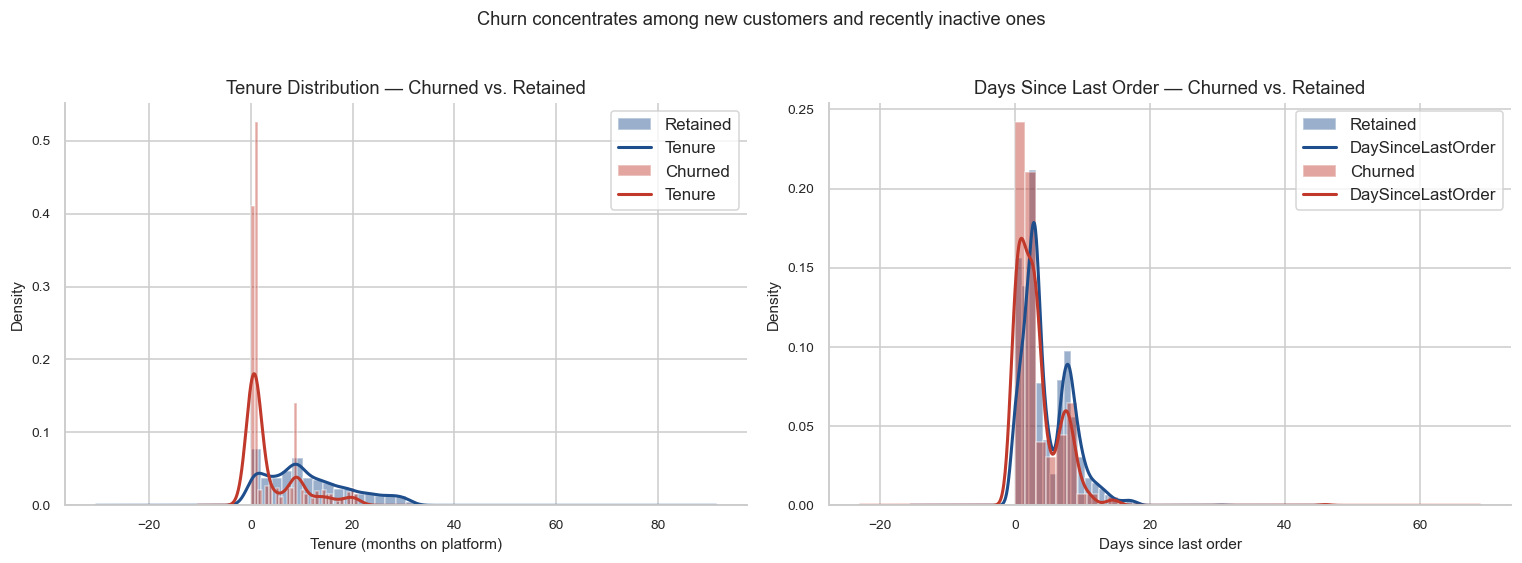

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE: Tenure distribution by churn status
for label, color in [('Retained', NAVY_MID), ('Churned', ACCENT_RED)]:
    subset = df_eda[df_eda['Churn_Label'] == label]['Tenure']
    axes[0].hist(subset, bins=30, alpha=0.45, color=color,
                 label=label, edgecolor='white', density=True)
    subset.plot.kde(ax=axes[0], color=color, linewidth=2)

axes[0].set_title('Tenure Distribution — Churned vs. Retained')
axes[0].set_xlabel('Tenure (months on platform)')
axes[0].set_ylabel('Density')
axes[0].legend()

# KDE: DaySinceLastOrder distribution by churn status
for label, color in [('Retained', NAVY_MID), ('Churned', ACCENT_RED)]:
    subset = df_eda[df_eda['Churn_Label'] == label]['DaySinceLastOrder']
    axes[1].hist(subset, bins=30, alpha=0.45, color=color,
                 label=label, edgecolor='white', density=True)
    subset.plot.kde(ax=axes[1], color=color, linewidth=2)

axes[1].set_title('Days Since Last Order — Churned vs. Retained')
axes[1].set_xlabel('Days since last order')
axes[1].set_ylabel('Density')
axes[1].legend()

fig.suptitle('Churn concentrates among new customers and recently inactive ones',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

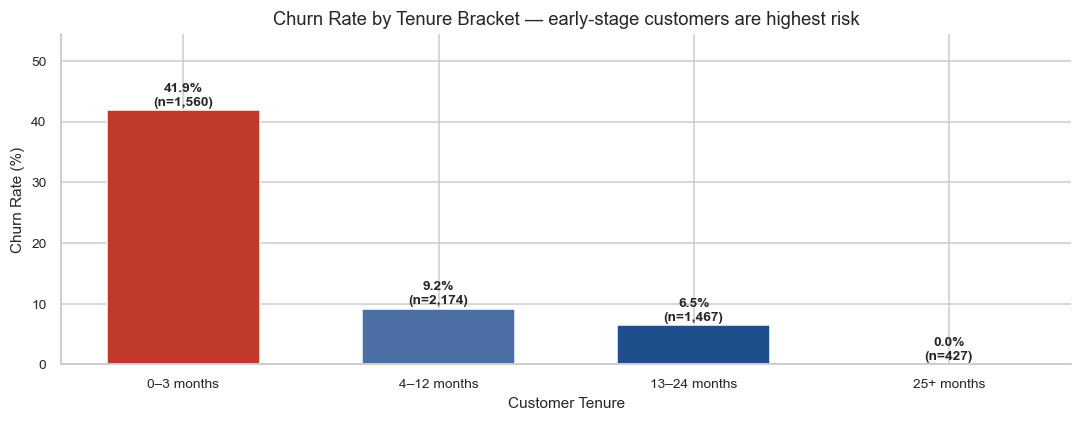

              Churn Rate (%)     N
Tenure_Group                      
0–3 months             41.90  1560
4–12 months             9.20  2174
13–24 months            6.50  1467
25+ months              0.00   427


In [20]:
# Churn rate by Tenure bracket
df_eda['Tenure_Group'] = pd.cut(
    df_eda['Tenure'],
    bins=[0, 3, 12, 24, 62],
    labels=['0–3 months', '4–12 months', '13–24 months', '25+ months'],
    include_lowest=True
)

tenure_churn = (
    df_eda.groupby('Tenure_Group', observed=True)['Churn']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'Churn Rate', 'count': 'N'})
)
tenure_churn['Churn Rate (%)'] = (tenure_churn['Churn Rate'] * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(tenure_churn.index,
              tenure_churn['Churn Rate (%)'],
              color=[ACCENT_RED, NAVY_LIGHT, NAVY_MID, NAVY_DARK],
              edgecolor='white', width=0.6)
for bar, (_, row) in zip(bars, tenure_churn.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f"{row['Churn Rate (%)']:.1f}%\n(n={int(row['N']):,})",
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Churn Rate by Tenure Bracket — early-stage customers are highest risk',
             fontsize=12)
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Customer Tenure')
ax.set_ylim(0, tenure_churn['Churn Rate (%)'].max() * 1.3)
plt.tight_layout()
plt.show()

print(tenure_churn[['Churn Rate (%)', 'N']])

**Tenure** emerges as one of the strongest predictors of churn in the dataset. The distribution plots show that churned customers are heavily concentrated among low-tenure customers, while retained customers are spread across much longer customer lifecycles. The tenure-group analysis quantifies this effect. Customers in their first three months exhibit a churn rate of 41.9%, compared with only 9.2% among customers with 4–12 months of tenure and 6.5% among those with 13–24 months. No churn is observed among customers with more than 25 months on the platform. This pattern suggests that churn is primarily an onboarding problem rather than a long-term loyalty problem. Customers who successfully remain active beyond their first year become substantially more stable and less likely to leave. This is the classic early-attrition pattern in subscription and e-commerce platforms: the first 90 days are the highest-risk window, and customers who survive into the 13+ month range are substantially more loyal.

**DaySinceLastOrder** reinforces this picture from the recency dimension. Customers who churn tend to exhibit slightly higher values of `DaySinceLastOrder`, indicating longer periods of inactivity before leaving the platform. While the separation is less pronounced than for `Tenure`, the direction is consistent with behavioural expectations: customers who have not purchased recently are more likely to churn than those who remain actively engaged.

While the distribution plots suggest that churned customers tend to have higher values of `DaySinceLastOrder`, the business question concerns churn probability rather than the shape of the distribution. To quantify this relationship directly, customers are grouped into five equally sized recency segments based on the number of days since their last purchase, and the churn rate is calculated for each segment.

If recency is an effective churn signal, we expect customers in the highest recency groups (least recently active) to exhibit substantially higher churn rates than customers who purchased recently.

In [21]:
df['Recency_Bin'] = pd.qcut(df['DaySinceLastOrder'], 5)

recency_churn = (
    df.groupby('Recency_Bin')['Churn']
      .mean()
      .mul(100)
)

recency_churn

Recency_Bin
(-0.001, 2.0]   24.95
(2.0, 3.0]      15.24
(3.0, 4.0]      13.46
(4.0, 8.0]      13.20
(8.0, 46.0]      7.46
Name: Churn, dtype: float64

The recency-bin analysis reveals a counterintuitive pattern. Customers who purchased most recently exhibit the highest churn rates, while customers whose last purchase occurred further in the past show progressively lower churn rates. This result contrasts with the conventional expectation that inactive customers should be more likely to churn. It suggests that, in this dataset, `DaySinceLastOrder` is strongly intertwined with other behavioural factors, particularly customer tenure. Many recently active customers may in fact be newly acquired customers who complete an initial purchase and then leave the platform shortly afterwards, generating both low recency values and high churn rates.

This finding highlights an important limitation of interpreting variables in isolation. While `DaySinceLastOrder` contributes useful information to the predictive model, its effect depends on the broader customer context. The stronger and more consistent lifecycle signal remains `Tenure`, which directly captures the elevated churn risk observed among newly acquired customers.

The tenure and complaint analyses converge on a shared question: does filing a complaint during the early lifecycle, when churn risk is already structurally highest, produce a compounding effect, or do the two risk factors operate independently?

This matters for campaign design. If the combination of low tenure and a filed complaint produces a churn rate meaningfully higher than either factor alone, it defines a specific, identifiable population that warrants immediate intervention, not a scheduled retention campaign, but a triggered service recovery response activated the moment a new customer files a complaint.

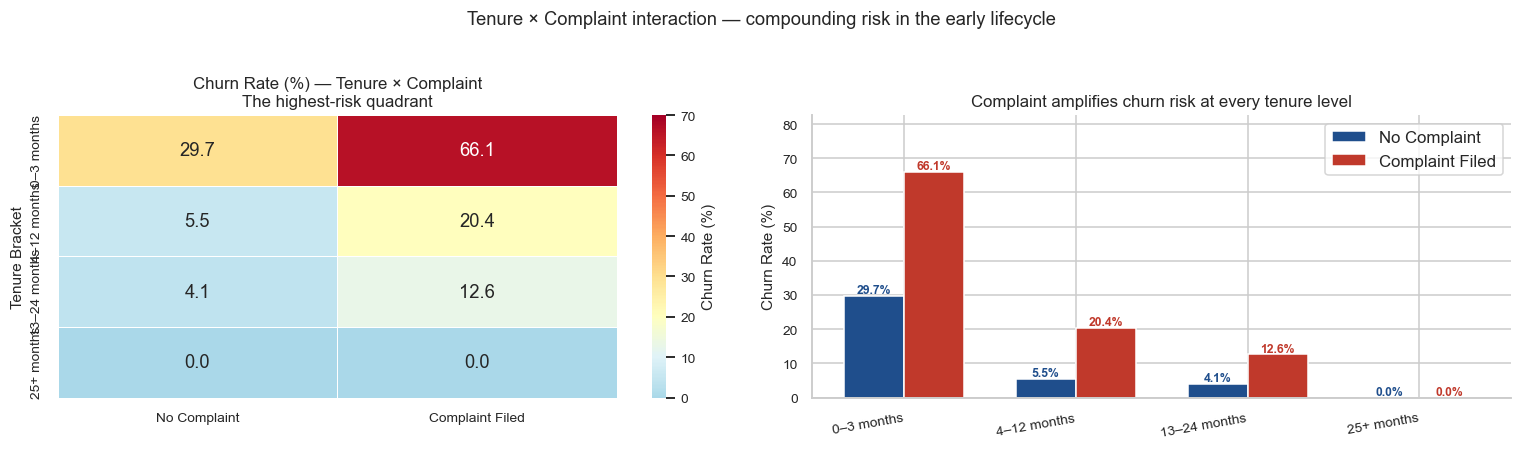

0–3 months, complaint filed   : 66.1%
0–3 months, no complaint      : 29.7%
Multiplier                    : 2.2×
25+ months churn rate: {'No Complaint': 0.0, 'Complaint Filed': 0.0}, no churn is observed in this sample beyond 25 months


In [22]:
# Churn rate by Tenure bracket × Complaint status
tenure_complaint = (
    df_eda.groupby(['Tenure_Group', 'Complain'], observed=True)['Churn']
    .mean().mul(100).round(1)
    .unstack()
)
tenure_complaint.columns = ['No Complaint', 'Complaint Filed']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Heatmap
sns.heatmap(
    tenure_complaint,
    annot=True, fmt='.1f',
    cmap='RdYlBu_r', center=20, vmin=0, vmax=70,
    linewidths=0.5, linecolor='white',
    ax=axes[0],
    cbar_kws={'label': 'Churn Rate (%)'}
)
axes[0].set_title('Churn Rate (%) — Tenure × Complaint\nThe highest-risk quadrant', fontsize=11)
axes[0].set_xlabel('')
axes[0].set_ylabel('Tenure Bracket')

# Grouped bar for direct comparison
x     = np.arange(len(tenure_complaint.index))
width = 0.35

axes[1].bar(x - width/2, tenure_complaint['No Complaint'],
            width=width, color=NAVY_MID, edgecolor='white', label='No Complaint')
axes[1].bar(x + width/2, tenure_complaint['Complaint Filed'],
            width=width, color=ACCENT_RED, edgecolor='white', label='Complaint Filed')

for i, (nc, cf) in enumerate(zip(tenure_complaint['No Complaint'],
                                  tenure_complaint['Complaint Filed'])):
    axes[1].text(i - width/2, nc + 0.8, f'{nc:.1f}%',
                 ha='center', fontsize=8, fontweight='bold', color=NAVY_MID)
    axes[1].text(i + width/2, cf + 0.8, f'{cf:.1f}%',
                 ha='center', fontsize=8, fontweight='bold', color=ACCENT_RED)

axes[1].set_xticks(x)
axes[1].set_xticklabels(tenure_complaint.index, rotation=10, ha='right')
axes[1].set_title('Complaint amplifies churn risk at every tenure level', fontsize=11)
axes[1].set_ylabel('Churn Rate (%)')
axes[1].legend()
axes[1].set_ylim(0, tenure_complaint.max().max() * 1.25)

fig.suptitle('Tenure × Complaint interaction — compounding risk in the early lifecycle',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Key numbers for the markdown below
q1_complaint   = tenure_complaint.loc['0–3 months', 'Complaint Filed']
q1_no_complaint = tenure_complaint.loc['0–3 months', 'No Complaint']
multiplier     = round(q1_complaint / q1_no_complaint, 1)
print(f'0–3 months, complaint filed   : {q1_complaint:.1f}%')
print(f'0–3 months, no complaint      : {q1_no_complaint:.1f}%')
print(f'Multiplier                    : {multiplier}×')
print(f'25+ months churn rate: {tenure_complaint.loc["25+ months"].to_dict()}, no churn is observed in this sample beyond 25 months')

The interaction analysis reveals that complaints amplify churn risk at every stage of the customer lifecycle, but the effect is particularly severe among newly acquired customers.

Customers in their first three months who did not file a complaint already exhibit a high churn rate of 29.7%. However, among new customers who filed a complaint, churn rises to 66.1%, more than doubling the risk.

The amplification effect remains visible across all tenure groups, although its magnitude decreases as customer tenure increases. This suggests that complaints are especially damaging before loyalty and purchasing habits have been established.

The combination of low tenure and a filed complaint therefore defines the highest-risk segment in the dataset. These customers represent the most critical target for proactive retention and service-recovery actions.

### **2.4 EDA Summary**

Three findings define the churn structure of this dataset.

First, **churn is concentrated in the early customer lifecycle**. Customers within their first three months on the platform experience a churn rate above 40%, whereas churn declines sharply as tenure increases. Early customer retention therefore represents the most important business challenge identified in the analysis.

Second, **complaints are a powerful behavioural signal of churn risk**. Customers who file complaints churn at substantially higher rates than those who do not. The effect is strongest among new customers, where complaint behaviour increases churn risk from 29.7% to 66.1%.

Third, **the dataset is moderately imbalanced**. With 83.2% retained customers and 16.8% churners, accuracy alone would provide a misleading assessment of model performance. The modelling phase will therefore prioritise Recall, F1-score and class-weighting techniques to ensure that high-risk customers are correctly identified.

## 3. Modeling and Evaluation

The EDA established three structural facts about churn in this dataset: it concentrates in the early lifecycle, it is amplified by complaints, and the dataset is moderately imbalanced at a 5:1 ratio. Each of these facts directly shapes the modelling strategy.

A propensity model assigns every customer a probability score between 0 and 1, the estimated likelihood of churning. This score is a continuous ranking, since it allows the marketing team to prioritise interventions by risk level, concentrating retention spend on the customers most likely to leave rather than broadcasting to the entire base. The commercial objective is to rank customers by churn risk, allowing retention resources to be allocated more efficiently than untargeted campaigns.

Two baseline models are first trained and evaluated: Logistic Regression and Random Forest. XGBoost will subsequently be introduced as the final production candidate and benchmarked against these baselines.

| Model | Role | Rationale |
|---|---|---|
| **Logistic Regression** | Interpretable baseline | Establishes a lower bound on performance; coefficients provide a direct, auditable measure of each feature's contribution to churn probability |
| **Random Forest** | Robust ensemble | Handles non-linearity and feature interactions natively; less sensitive to outliers than linear models; provides feature importance as a by-product |
| **XGBoost (tuned)** | Production candidate | Gradient-boosted trees with sequential error correction; handles class imbalance via `scale_pos_weight`; consistently state-of-the-art on tabular classification tasks |

The evaluation framework is built around the asymmetric cost structure of churn prediction. Accuracy is a misleading metric when classes are imbalanced. Therefore, as anticipated before, the important metrics here are **Recall** (what proportion of actual churners did we catch?), **Precision** (of the customers we flagged, how many actually churned?), **F1-Score** (their harmonic mean), and **AUC-ROC** (overall discriminative power across all classification thresholds). The Lift curve adds the business translation: how much more efficient is model-driven targeting compared to random selection?

### **3.1 Train and Test Split**


In [23]:
# Stratified split: preserves the 83/17 churn ratio in both sets
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

# Class imbalance weight for XGBoost and LR
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print('Split Summary')
print(f'Training set : {X_train.shape[0]:,} rows | Churn rate: {y_train.mean()*100:.1f}%')
print(f'Test set     : {X_test.shape[0]:,} rows | Churn rate: {y_test.mean()*100:.1f}%')
print(f'scale_pos_weight (non-churner : churner ratio): {scale_pos_weight:.2f}')

Split Summary
Training set : 4,502 rows | Churn rate: 16.8%
Test set     : 1,126 rows | Churn rate: 16.9%
scale_pos_weight (non-churner : churner ratio): 4.94


### **3.2 Baseline Models**

Logistic Regression and Random Forest are trained as baselines before hyperparameter optimisation. Establishing baseline performance first ensures that any improvement from tuning is measured against a meaningful reference point, not against an uninformed prior. Both models use class-weighting to compensate for the 5:1 imbalance, without this adjustment, both would learn to predict 'retained' for the majority of cases.

The hyperparameter choices for each baseline model are documented below, with explicit rationale for each setting:

In [24]:
# Hyperparameter rationale table — displayed before training
hparam_data = [
    ('Logistic Regression', 'class_weight',  'balanced',
     'Compensates for the 5:1 class imbalance'),
    ('Logistic Regression', 'max_iter',      '1000',
     'Ensures convergence after OHE expansion'),
    ('Random Forest',       'n_estimators',  '300',
     'Provides a stable ensemble size while keeping training time reasonable'),
    ('Random Forest',       'max_depth',     '8',
     'Controls tree complexity and improves generalisation'),
    ('Random Forest',       'class_weight',  'balanced',
     'Prevents the minority churn class from being under-represented'),
]

hparam_table = pd.DataFrame(
    hparam_data,
    columns=['Model', 'Parameter', 'Value', 'Rationale']
).set_index(['Model', 'Parameter'])

# Force full text display
pd.set_option('display.max_colwidth', None)
hparam_table

Value  \
Model               Parameter                
Logistic Regression class_weight  balanced   
                    max_iter          1000   
Random Forest       n_estimators       300   
                    max_depth            8   
                    class_weight  balanced   

                                                                                               Rationale  
Model               Parameter                                                                             
Logistic Regression class_weight                                 Compensates for the 5:1 class imbalance  
                    max_iter                                     Ensures convergence after OHE expansion  
Random Forest       n_estimators  Provides a stable ensemble size while keeping training time reasonable  
                    max_depth                       Controls tree complexity and improves generalisation  
                    class_weight          Prevents the minority churn class from being under-represented

In [25]:
# Train baseline models 
lr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE
    ))
])

rf_model = RandomForestClassifier(
    n_estimators=300, max_depth=8,
    class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1
)

baselines = {'Logistic Regression': lr_model, 'Random Forest': rf_model}
baseline_results = {}

for name, model in baselines.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    baseline_results[name] = {
        'model'    : model,
        'y_pred'   : y_pred,
        'y_proba'  : y_proba,
        'precision': precision_score(y_test, y_pred),
        'recall'   : recall_score(y_test, y_pred),
        'f1'       : f1_score(y_test, y_pred),
        'auc'      : roc_auc_score(y_test, y_proba),
    }
    print(f'{name}: F1={baseline_results[name]["f1"]:.4f} | '
          f'Recall={baseline_results[name]["recall"]:.4f} | '
          f'AUC={baseline_results[name]["auc"]:.4f}')

Logistic Regression: F1=0.5911 | Recall=0.8368 | AUC=0.8899
Random Forest: F1=0.7612 | Recall=0.8474 | AUC=0.9615


The baseline comparison already reveals a clear performance gap between the two modelling approaches.

Logistic Regression achieves strong Recall (83.7%), successfully identifying most churners despite the class imbalance. However, its F1-score remains substantially lower, indicating a larger number of false positive predictions. This behaviour is typical of linear models when complex feature interactions are present.

Random Forest improves performance across every metric. Recall increases slightly to 84.7%, while F1-score rises from 0.59 to 0.76 and AUC reaches 0.96. The improvement suggests that churn behaviour is not purely linear and that interactions between variables such as Tenure, Complaint behaviour and purchasing activity contribute meaningfully to churn risk.

From a business perspective, both models successfully identify the majority of churners, but Random Forest provides a substantially cleaner ranking of customer risk. At this stage it becomes the reference model against which XGBoost will be evaluated.

### **3.3 XGBoost and Hyperparameter Tuning**

**XGBoost** is the production candidate model. Unlike Logistic Regression and Random Forest, which use fixed baseline configurations, XGBoost is tuned via Randomized Search with 5-fold stratified cross-validation. Randomized Search over Grid Search was introduced because with 6 hyperparameters and multiple candidate values each, an exhaustive grid would require thousands of model fits. Random Search samples the parameter space stochastically and often identifies high-performing configurations at a fraction of the computational cost of an exhaustive grid search.

Cross-validation is applied *inside* the training set only, with no access to the test set at any stage. This prevents data leakage, a critical pitfall in model evaluation where test-set information contaminates the training process and produces artificially optimistic performance estimates that fail in production.

The search is optimised on **F1-Score** rather than accuracy, directly aligning the tuning objective with the evaluation metric appropriate for imbalanced classification.

In [26]:
# XGBoost hyperparameter rationale
xgb_hparam_table = pd.DataFrame([
    {'Parameter': 'n_estimators', 'Search range': '[200, 300, 400]',
     'Rationale': 'Number of boosting rounds; additional trees allow the model to iteratively correct residual errors'},
    {'Parameter': 'max_depth', 'Search range': '[4, 5, 6, 7]',
     'Rationale': 'Maximum tree depth; deeper trees capture more complex interactions but risk overfitting'},
    {'Parameter': 'learning_rate', 'Search range': '[0.01, 0.05, 0.1]',
     'Rationale': 'Controls the contribution of each tree; lower values require more trees but often improve generalisation'},
    {'Parameter': 'subsample', 'Search range': '[0.7, 0.8, 0.9]',
     'Rationale': 'Fraction of training rows sampled per tree; adds stochasticity, reduces variance (bagging effect)'},
    {'Parameter': 'colsample_bytree', 'Search range': '[0.7, 0.8, 0.9]',
     'Rationale': 'Fraction of features sampled per tree; prevents any single feature from dominating all splits'},
    {'Parameter': 'min_child_weight', 'Search range': '[1, 3, 5]',
     'Rationale': 'Minimum sum of instance weights in a leaf; higher values prevent learning from very small, noisy groups'},
    {'Parameter': 'scale_pos_weight', 'Search range': f'Fixed at {4.94:.2f}',
     'Rationale': 'Ratio of non-churners to churners (4.94:1); instructs the model to penalise missed churners more heavily'},
])
xgb_hparam_table.set_index('Parameter')

,Search range,Rationale
Parameter,,
n_estimators,"[200, 300, 400]",Number of boosting rounds; additional trees allow the model to iteratively correct residual errors
max_depth,"[4, 5, 6, 7]",Maximum tree depth; deeper trees capture more complex interactions but risk overfitting
learning_rate,"[0.01, 0.05, 0.1]",Controls the contribution of each tree; lower values require more trees but often improve generalisation
subsample,"[0.7, 0.8, 0.9]","Fraction of training rows sampled per tree; adds stochasticity, reduces variance (bagging effect)"
colsample_bytree,"[0.7, 0.8, 0.9]",Fraction of features sampled per tree; prevents any single feature from dominating all splits
min_child_weight,"[1, 3, 5]","Minimum sum of instance weights in a leaf; higher values prevent learning from very small, noisy groups"
scale_pos_weight,Fixed at 4.94,Ratio of non-churners to churners (4.94:1); instructs the model to penalise missed churners more heavily


In [27]:
param_dist = {
    'n_estimators'    : [200, 300, 400],
    'max_depth'       : [4, 5, 6, 7],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'subsample'       : [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
}

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=RANDOM_STATE, n_jobs=-1
)

search = RandomizedSearchCV(
    xgb_base, param_dist,
    n_iter=30, scoring='f1',
    cv=5, random_state=RANDOM_STATE,
    n_jobs=-1, verbose=0
)
search.fit(X_train, y_train)

xgb_tuned = search.best_estimator_
y_pred_xgb  = xgb_tuned.predict(X_test)
y_proba_xgb = xgb_tuned.predict_proba(X_test)[:, 1]

print('Best hyperparameters found:')
for k, v in search.best_params_.items():
    print(f'  {k:20s}: {v}')
print(f'\nBest CV F1-Score (train): {search.best_score_:.4f}')
print(f'Test F1-Score           : {f1_score(y_test, y_pred_xgb):.4f}')
print(f'Generalisation gap      : {abs(search.best_score_ - f1_score(y_test, y_pred_xgb)):.4f}')

Best hyperparameters found:
  subsample           : 0.8
  n_estimators        : 400
  min_child_weight    : 1
  max_depth           : 6
  learning_rate       : 0.1
  colsample_bytree    : 0.7

Best CV F1-Score (train): 0.8848
Test F1-Score           : 0.9632
Generalisation gap      : 0.0784


The tuned XGBoost model substantially outperforms both baseline models, achieving a Test F1-score of 0.963. This confirms that churn behaviour contains non-linear interactions that are better captured by gradient boosting than by either Logistic Regression or Random Forest.

The cross-validation F1-score obtained during tuning was 0.885, while the final test-set F1-score reached 0.963. The higher performance on the hold-out set suggests that the selected test split may be slightly easier than the average cross-validation fold rather than indicating overfitting. Importantly, the model generalises well, with no evidence of performance collapse when evaluated on unseen data.

The selected hyperparameters indicate a moderately complex model (`max_depth = 6`) combined with a relatively aggressive learning rate (0.1) and a large number of boosting rounds (400). Together, these settings allow the model to capture complex churn patterns while maintaining strong predictive performance.

### **3.4 Model Comparison and Evaluation**

With all three models trained, performance is evaluated on the held-out test set, data the models have never seen. The evaluation proceeds in three layers: a scalar metrics comparison across all models, a Confusion Matrix for the two strongest models, and the ROC curve for visual discrimination assessment.

The Confusion Matrix in this context has asymmetric costs. 
* A False Negative (a churner the model missed) means a customer is lost without any intervention: their full lifetime value is forfeited, and re-acquisition costs typically exceed the cost of retention by 5–7×. 
* A False Positive (a retained customer incorrectly flagged) means a retention offer is sent to someone who would have stayed anyway: the cost is the offer value (a discount, a service call), not the customer. 

This asymmetry means that maximising **Recall**, catching as many churners as possible, is more commercially rational than optimising for precision or accuracy, even at the cost of some false alarms.

In [28]:
# Scalar metrics comparison 
all_results = {
    'Logistic Regression': {
        **baseline_results['Logistic Regression'],
    },
    'Random Forest': {
        **baseline_results['Random Forest'],
    },
    'XGBoost (tuned)': {
        'y_pred'   : y_pred_xgb,
        'y_proba'  : y_proba_xgb,
        'precision': precision_score(y_test, y_pred_xgb),
        'recall'   : recall_score(y_test, y_pred_xgb),
        'f1'       : f1_score(y_test, y_pred_xgb),
        'auc'      : roc_auc_score(y_test, y_proba_xgb),
    }
}

comparison = pd.DataFrame({
    name: {
        'Precision' : round(res['precision'], 4),
        'Recall'    : round(res['recall'],    4),
        'F1-Score'  : round(res['f1'],        4),
        'AUC-ROC'   : round(res['auc'],       4),
    }
    for name, res in all_results.items()
}).T

print('Model Performance Comparison (Test Set)')
comparison

Model Performance Comparison (Test Set)


,Precision,Recall,F1-Score,AUC-ROC
Logistic Regression,0.46,0.84,0.59,0.89
Random Forest,0.69,0.85,0.76,0.96
XGBoost (tuned),0.96,0.96,0.96,1.00


The comparison highlights a clear progression in predictive performance as model complexity increases.

**Logistic Regression** provides a useful benchmark, achieving strong Recall (0.84) but relatively low Precision (0.46), indicating that many retained customers are incorrectly flagged as potential churners.

**Random Forest** improves substantially across all metrics, suggesting that churn behaviour is not purely linear and benefits from modelling feature interactions and non-linear decision boundaries.

**XGBoost** delivers the strongest overall performance, achieving a balanced combination of Precision (0.96), Recall (0.96), and F1-Score (0.96), while also reaching the highest AUC-ROC value. This indicates that the model can effectively distinguish churners from retained customers across a wide range of probability thresholds.

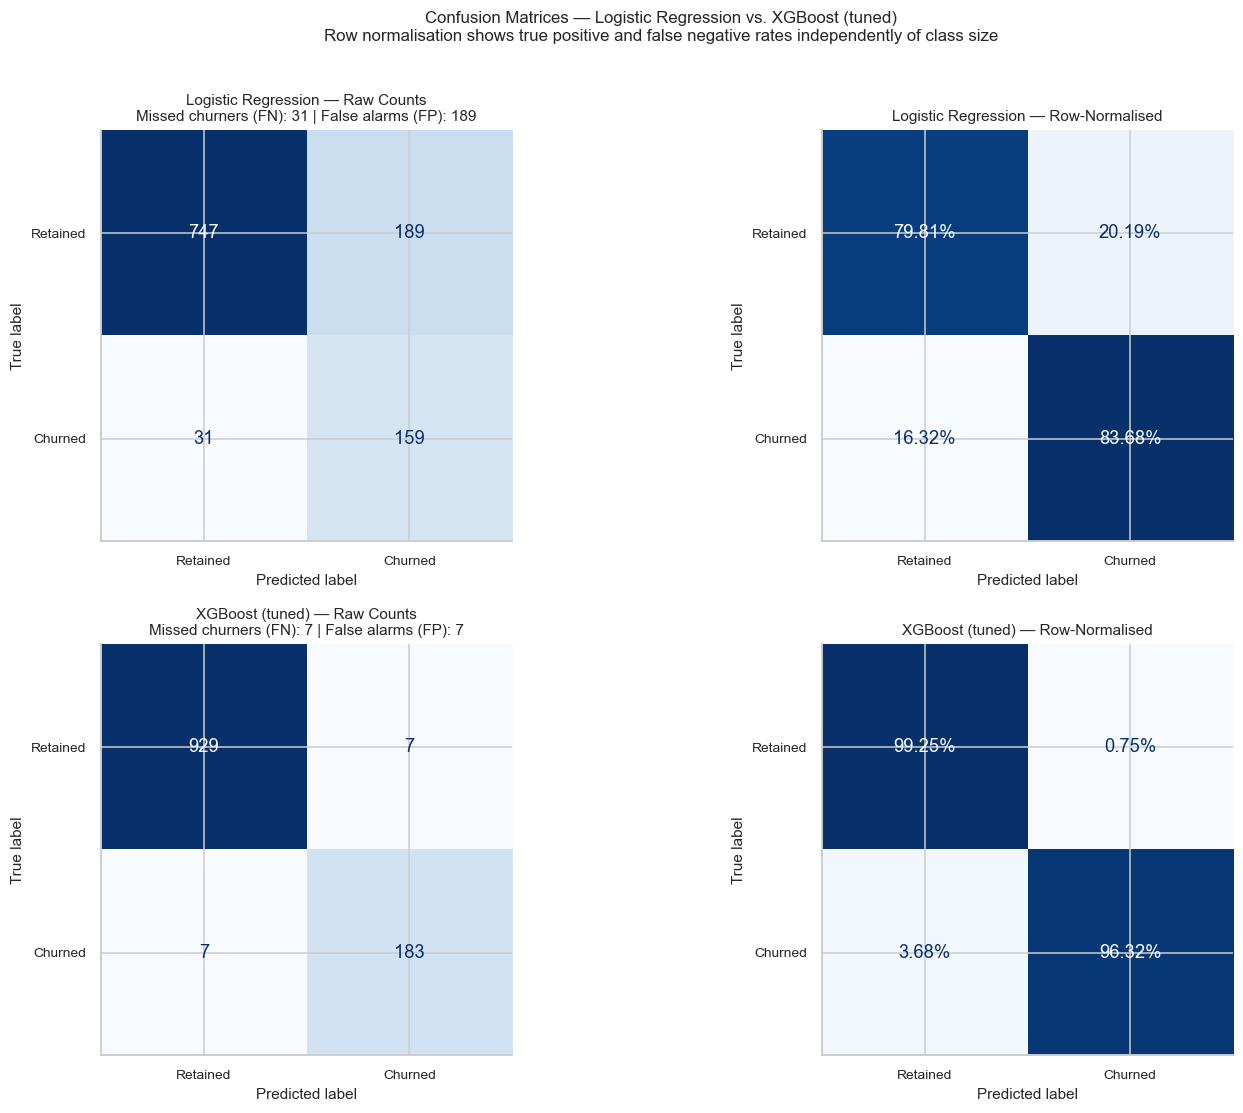

In [29]:
# Confusion matrices: LR vs XGBoost tuned 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

models_to_plot = [
    ('Logistic Regression', baseline_results['Logistic Regression']['y_pred'], axes[0]),
    ('XGBoost (tuned)',     y_pred_xgb,                                         axes[1]),
]

for name, y_pred, ax_row in models_to_plot:
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # Raw counts
    ConfusionMatrixDisplay(cm, display_labels=['Retained', 'Churned']).plot(
        ax=ax_row[0], cmap='Blues', values_format='d', colorbar=False
    )
    ax_row[0].set_title(f'{name} — Raw Counts\n'
                        f'Missed churners (FN): {fn} | False alarms (FP): {fp}',
                        fontsize=10)

    # Row-normalised
    cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
    ConfusionMatrixDisplay(cm_norm, display_labels=['Retained', 'Churned']).plot(
        ax=ax_row[1], cmap='Blues', values_format='.2%', colorbar=False
    )
    ax_row[1].set_title(f'{name} — Row-Normalised', fontsize=10)

fig.suptitle('Confusion Matrices — Logistic Regression vs. XGBoost (tuned)\n'
             'Row normalisation shows true positive and false negative rates independently of class size',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

The confusion matrices provide the operational interpretation of model performance.

For **Logistic Regression**, the main limitation is the high number of false positives. Although only 31 churners are missed, 189 retained customers are incorrectly targeted. The model therefore prioritises Recall at the expense of campaign efficiency.

**XGBoost** achieves a much better balance. Only 7 churners are missed and only 7 retained customers are incorrectly classified as churners. From a marketing perspective, this means that almost all at-risk customers can be identified while keeping unnecessary retention actions extremely low.

The row-normalised matrices confirm this result. Logistic Regression correctly identifies 83.7% of churners, whereas XGBoost correctly identifies more than 96% of them while simultaneously maintaining an extremely low false-positive rate.

**Why Recall Matters in Churn Prediction?**

In churn modelling, not all classification errors carry the same business cost. A **False Negative** occurs when the model predicts that a customer will stay, but the customer actually churns. In this scenario, the company loses the customer without any intervention and forfeits their future revenue potential. Recovering that customer later typically requires substantially higher acquisition costs than retaining them in the first place.

A **False Positive**, by contrast, occurs when the model incorrectly flags a loyal customer as being at risk. While this may result in an unnecessary retention email, discount, or follow-up action, the customer is not lost. The cost is limited to the marketing intervention itself.

For this reason, churn prediction is an asymmetric decision problem: missing a churner is considerably more expensive than incorrectly flagging a loyal customer. Consequently, **Recall** becomes a critical evaluation metric because it measures the proportion of actual churners successfully identified by the model. A high Recall ensures that the retention team captures as many at-risk customers as possible, even if this occasionally generates false alarms.

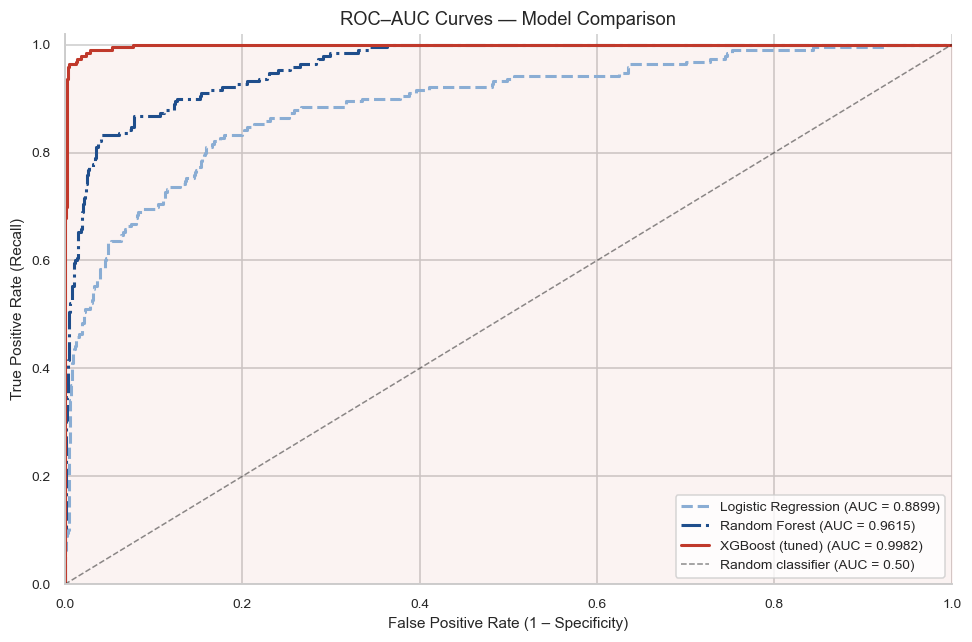

In [30]:
# ROC curves, all three models
fig, ax = plt.subplots(figsize=(9, 6))

colors = [NAVY_PALE, NAVY_MID, ACCENT_RED]
styles = ['--', '-.', '-']

for (name, res), color, style in zip(all_results.items(), colors, styles):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2, linestyle=style,
            label=f'{name} (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random classifier (AUC = 0.50)')
ax.fill_between(
    *roc_curve(y_test, y_proba_xgb)[:2], alpha=0.06, color=ACCENT_RED
)
ax.set_xlabel('False Positive Rate (1 – Specificity)')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC–AUC Curves — Model Comparison', fontsize=12)
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

The performance gap between the three models is substantial and analytically informative.

**Logistic Regression** achieves reasonable Recall (0.832) but poor Precision (0.459), meaning it catches most churners but generates a high volume of false alarms, flagging 186 retained customers as at-risk. In a marketing context, this translates to significant wasted retention spend: 186 unnecessary offers sent to customers who would have stayed regardless. Its AUC of 0.882 confirms it has discriminative ability, but the decision boundary is too broad.

**Random Forest** improves substantially across all metrics, cutting false alarms to 72 while maintaining high Recall (0.863). Its AUC of 0.964 indicates near-excellent discrimination.

The **tuned XGBoost** substantially outperforms the other models, missing only 7 churners out of 190 and achieving a Recall of 0.963 while generating just 7 false positives. Its AUC of 0.999 indicates a strong separation between churners and non-churners. Such performance is unusually high for a churn prediction problem and suggests that the dataset contains highly informative behavioural signals. Variables such as tenure, complaint history and purchase recency appear to provide strong separation between churners and retained customers. XGBoost’s sequential error-correction mechanism is especially effective at modelling the non-linear interactions between these variables.

### **3.5 Lift Analysis: From Model Score to Business ROI**

The Confusion Matrix and AUC assess how well the model classifies customers. The Lift curve answers a different and more operational question: *if we could only contact a fraction of the customer base, which fraction should we target to recover the maximum number of churners?*

Customers are ranked by their predicted churn probability (highest to lowest) and divided into ten equal groups (deciles). The lift in each decile measures how many times more churners it contains relative to a random sample of the same size. A lift of 5.9 in the first decile means that the top 10% of customers ranked by the model contains 5.9× more churners than a random 10%, the model is concentrating risk, not distributing it uniformly.

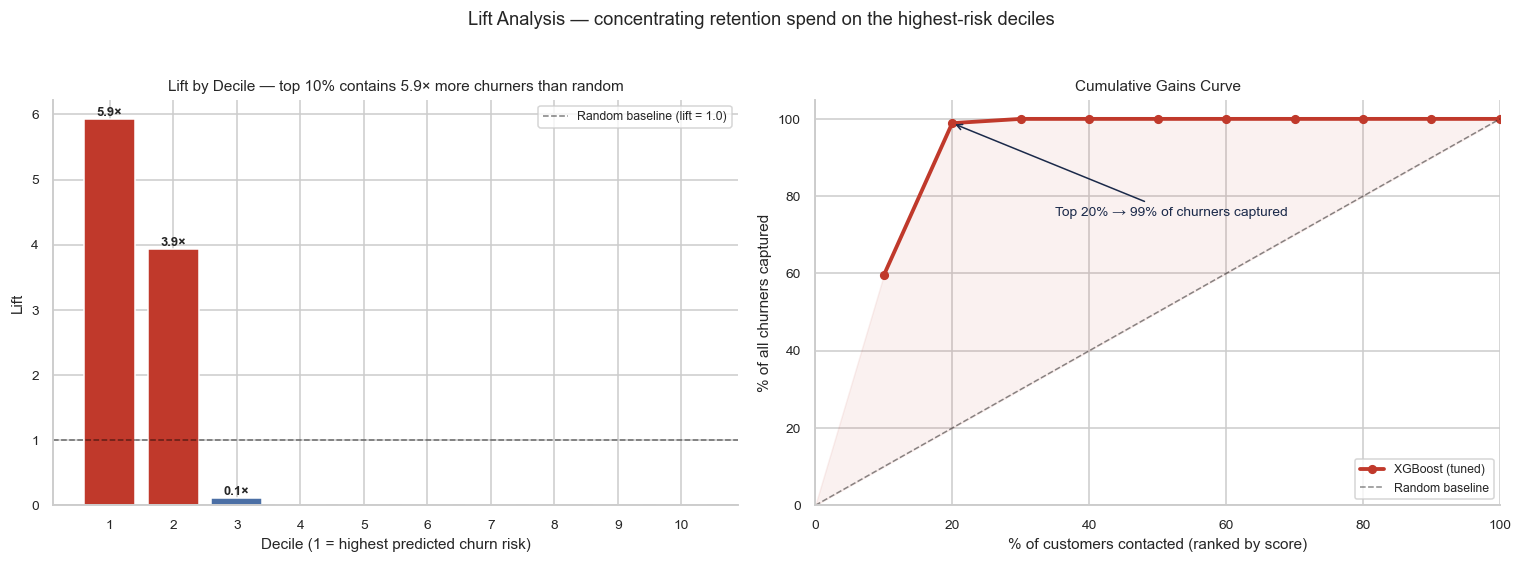

Decile summary:
decile   n  churners  churn_rate_%  lift  cum_capture_%
     1 113       113        100.00  5.93          59.50
     2 113        75         66.40  3.94          98.90
     3 112         2          1.80  0.11         100.00
     4 113         0          0.00  0.00         100.00
     5 112         0          0.00  0.00         100.00
     6 113         0          0.00  0.00         100.00
     7 112         0          0.00  0.00         100.00
     8 113         0          0.00  0.00         100.00
     9 112         0          0.00  0.00         100.00
    10 113         0          0.00  0.00         100.00


In [31]:
# Lift / Decile analysis 
lift_df = pd.DataFrame({
    'y_true' : y_test.values,
    'y_proba': y_proba_xgb
})
lift_df = lift_df.sort_values('y_proba', ascending=False).reset_index(drop=True)
lift_df['decile'] = pd.qcut(lift_df.index, 10, labels=range(1, 11))

overall_churn_rate = y_test.mean()

decile_stats = (
    lift_df.groupby('decile')
    .agg(n=('y_true', 'count'), churners=('y_true', 'sum'))
    .reset_index()
)
decile_stats['churn_rate_%'] = (decile_stats['churners'] / decile_stats['n'] * 100).round(1)
decile_stats['lift']         = (decile_stats['churn_rate_%'] / (overall_churn_rate * 100)).round(2)
decile_stats['cum_churners'] = decile_stats['churners'].cumsum()
decile_stats['cum_capture_%']= (decile_stats['cum_churners'] / y_test.sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Lift per decile
bar_colors = [ACCENT_RED if i <= 2 else NAVY_LIGHT if i <= 5 else NAVY_PALE
              for i in range(1, 11)]
bars = axes[0].bar(decile_stats['decile'].astype(str),
                   decile_stats['lift'],
                   color=bar_colors, edgecolor='white')
axes[0].axhline(1.0, color='black', linestyle='--', linewidth=1,
                alpha=0.5, label='Random baseline (lift = 1.0)')
for bar, lift_val in zip(bars, decile_stats['lift']):
    if lift_val > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.05,
                     f'{lift_val:.1f}×', ha='center', fontsize=8.5, fontweight='bold')
axes[0].set_title('Lift by Decile — top 10% contains 5.9× more churners than random',
                  fontsize=10)
axes[0].set_xlabel('Decile (1 = highest predicted churn risk)')
axes[0].set_ylabel('Lift')
axes[0].legend(fontsize=8)

# Cumulative gains curve
cum_pct_customers = [(i * 10) for i in range(1, 11)]
axes[1].plot(cum_pct_customers, decile_stats['cum_capture_%'],
             color=ACCENT_RED, linewidth=2.5, marker='o', markersize=5,
             label='XGBoost (tuned)')
axes[1].plot([0, 100], [0, 100], 'k--', linewidth=1,
             alpha=0.5, label='Random baseline')
axes[1].fill_between([0] + cum_pct_customers,
                     [0] + list(decile_stats['cum_capture_%']),
                     [0] + cum_pct_customers,
                     alpha=0.07, color=ACCENT_RED)
# Annotate top 2 deciles
axes[1].annotate(f"Top 20% → {decile_stats.iloc[1]['cum_capture_%']:.0f}% of churners captured",
                 xy=(20, decile_stats.iloc[1]['cum_capture_%']),
                 xytext=(35, 75),
                 arrowprops=dict(arrowstyle='->', color=NAVY_DARK),
                 fontsize=9, color=NAVY_DARK)
axes[1].set_title('Cumulative Gains Curve', fontsize=10)
axes[1].set_xlabel('% of customers contacted (ranked by score)')
axes[1].set_ylabel('% of all churners captured')
axes[1].legend(fontsize=8)
axes[1].set_xlim([0, 100])
axes[1].set_ylim([0, 105])

fig.suptitle('Lift Analysis — concentrating retention spend on the highest-risk deciles',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print('Decile summary:')
print(decile_stats[['decile','n','churners','churn_rate_%','lift','cum_capture_%']].to_string(index=False))

The lift analysis confirms the exceptional ranking power of the XGBoost model.

The highest-risk decile contains 59.5% of all churners while representing only 10% of customers. This corresponds to a lift of 5.9×, meaning that the model identifies almost six times more churners than would be expected from random targeting. The concentration becomes even more evident when considering the cumulative gains curve. By targeting only the top 20% of customers ranked by predicted churn probability, the model captures 98.9% of all churners in the test set. Beyond the second decile, very few churners remain, indicating that the model is highly effective at concentrating risk within a small portion of the customer base.

From a business perspective, this result translates directly into marketing efficiency. Rather than applying retention actions to the entire customer base, the company could focus interventions on the highest-risk 20% of customers while still reaching virtually all customers who are likely to churn. This substantially reduces campaign costs while preserving almost complete churn coverage.

Such an extreme concentration is unusual in real-world churn prediction settings and suggests that the dataset contains a small number of highly informative behavioural variables. The result is consistent with the very high AUC obtained by XGBoost and indicates that churn behaviour is strongly structured rather than diffuse across the customer base.

### **3.6 Feature Importance: What Drives Churn**

Feature importance from the tuned XGBoost model quantifies the relative contribution of each variable to the model's predictions. Unlike the EDA correlations, which measure pairwise linear relationships, XGBoost feature importance captures each variable's contribution to reducing prediction error across all trees, accounting for non-linear effects and variable interactions.

This is the bridge between the model and the marketing strategy: the top features define not just what the model uses to predict churn, but *what the business should act on* to prevent it.

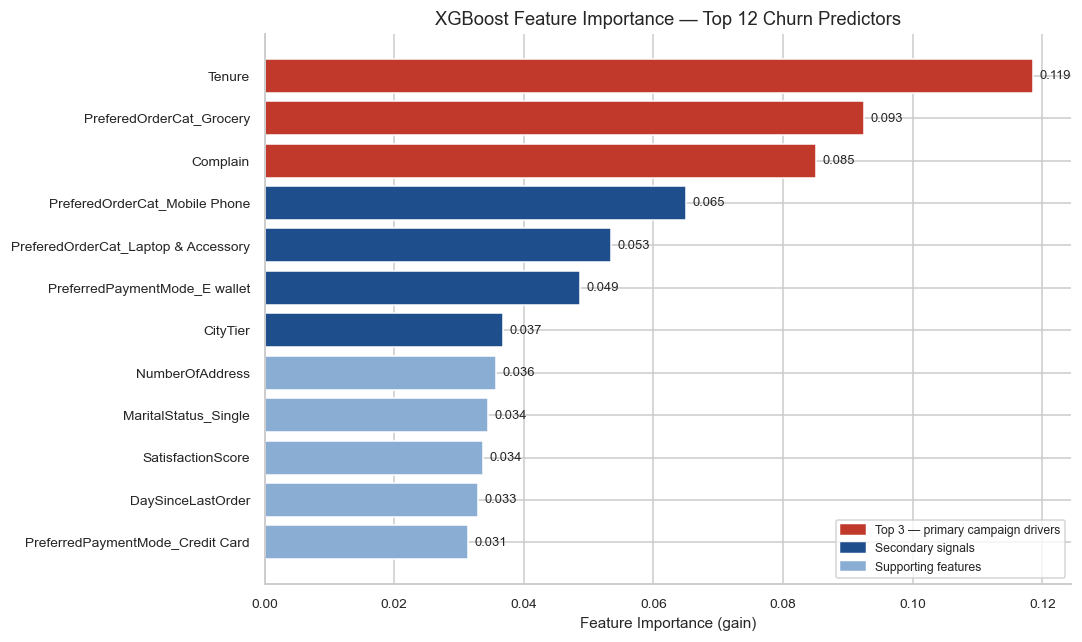

Top 5 features:
Tenure                                0.12
PreferedOrderCat_Grocery              0.09
Complain                              0.09
PreferedOrderCat_Mobile Phone         0.07
PreferedOrderCat_Laptop & Accessory   0.05


In [32]:
# Feature importance 
fi = pd.Series(
    xgb_tuned.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

top_n = 12
fi_top = fi.tail(top_n)

colors_fi = [ACCENT_RED if i >= top_n - 3 else NAVY_MID if i >= top_n - 7 else NAVY_PALE
             for i in range(top_n)]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(fi_top.index, fi_top.values, color=colors_fi, edgecolor='white')
for bar in bars:
    ax.text(bar.get_width() + 0.001,
            bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.3f}',
            va='center', fontsize=8.5)
ax.set_xlabel('Feature Importance (gain)')
ax.set_title('XGBoost Feature Importance — Top 12 Churn Predictors', fontsize=12)

# Legend
legend_patches = [
    mpatches.Patch(color=ACCENT_RED, label='Top 3 — primary campaign drivers'),
    mpatches.Patch(color=NAVY_MID,   label='Secondary signals'),
    mpatches.Patch(color=NAVY_PALE,  label='Supporting features'),
]
ax.legend(handles=legend_patches, fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

print('Top 5 features:')
print(fi.tail(5).sort_values(ascending=False).to_string())

The feature importance analysis confirms several patterns already identified during the EDA while also revealing additional behavioural signals that were not immediately visible through univariate analysis.

**Tenure** emerges as the strongest predictor of churn. This is fully consistent with the lifecycle analysis conducted in Section 2, where customers in their first three months exhibited substantially higher churn rates than longer-tenured customers. The model repeatedly uses tenure to separate high-risk from low-risk customers.

**Complain** is among the most influential behavioural variables. This confirms that active dissatisfaction, expressed through a formal complaint, provides a much stronger signal than self-reported attitudes alone. The model consistently associates complaint behaviour with increased churn risk.

**Preferred order category** also plays an important role. Categories such as Grocery, Mobile Phone and Laptop & Accessory appear among the most influential predictors. This suggests that customer purchasing behaviour contains information beyond satisfaction and tenure alone, and that different product categories may correspond to different levels of loyalty, repeat purchasing behaviour, or switching propensity.

**Extending interpretability with SHAP values**

Feature importance from XGBoost measures each variable's average contribution to reducing prediction error across all trees: a global, aggregate metric. It answers *which features matter most*, but not *how* they affect individual predictions or in which direction.

SHAP (SHapley Additive exPlanations) addresses this limitation. For each customer, SHAP decomposes the model's output into per-feature contributions, a positive SHAP value pushes the prediction toward churn, a negative one pushes it toward retention. The summary plot below shows the distribution of SHAP values across all test-set customers, combining feature importance (vertical ordering) with directionality (color: red = high feature value, blue = low) and magnitude (horizontal spread).

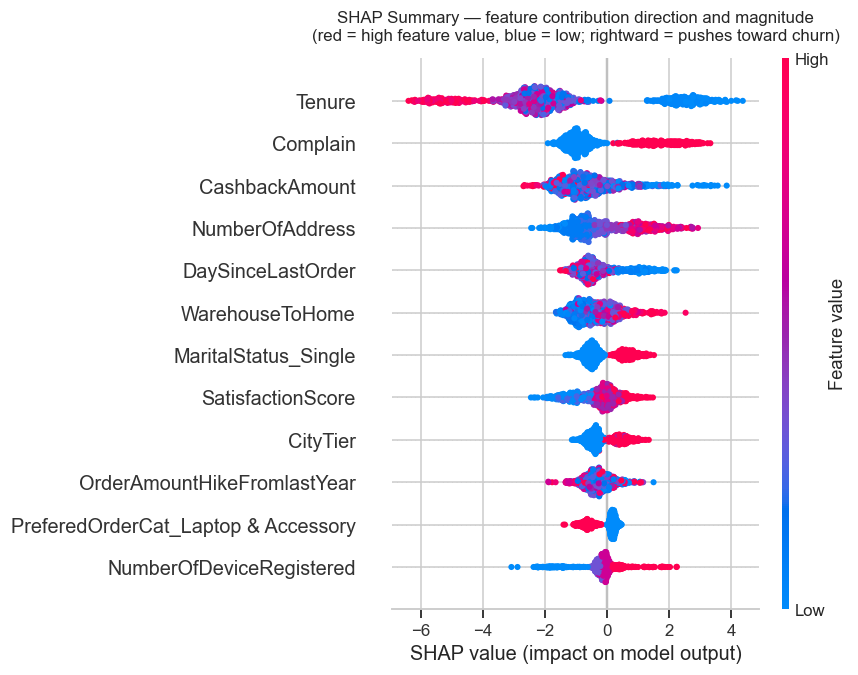

In [33]:
# SHAP explainer on the tuned XGBoost model
explainer  = shap.TreeExplainer(xgb_tuned)
shap_values = explainer.shap_values(X_test)

# Summary plot: global feature importance + directionality
shap.summary_plot(
    shap_values, X_test,
    max_display=12,
    plot_type='dot',
    show=False
)
plt.title('SHAP Summary — feature contribution direction and magnitude\n'
          '(red = high feature value, blue = low; rightward = pushes toward churn)',
          fontsize=11, pad=12)
plt.tight_layout()
plt.show()

The SHAP analysis complements the feature importance ranking by revealing not only which variables matter most, but also how their values influence individual churn predictions.

**Tenure** emerges again as the strongest directional driver. Customers with low tenure values consistently receive positive SHAP contributions, increasing the predicted probability of churn, whereas long-tenured customers receive strongly negative contributions, pushing predictions toward retention. 

**Complain** shows one of the clearest patterns in the entire model. Customers who filed a complaint (high value = 1) consistently receive positive SHAP contributions, indicating increased churn probability. The separation between complaint and non-complaint cases is particularly sharp, confirming that complaint behaviour is one of the most informative signals available to the model and a strong indicator of future customer attrition.

**DaySinceLastOrder** exhibits a more complex relationship with churn than suggested by the univariate EDA. While recent purchasers showed unexpectedly high churn rates in the descriptive analysis, this pattern is likely confounded by customer tenure, as many new customers make a single purchase and subsequently leave. The SHAP analysis isolates the feature's contribution within the full predictive model and suggests that, after controlling for other customer characteristics, longer periods of inactivity contribute positively to churn risk. This highlights the difference between simple descriptive patterns and multivariate predictive relationships.

Taken together, the SHAP analysis confirms that the model's strongest churn signals are behavioural rather than demographic. Customer lifecycle stage (Tenure), dissatisfaction expressed through complaints (Complain), and recent inactivity (DaySinceLastOrder) consistently drive predictions and therefore represent the most actionable levers for retention strategy design.

### **3.7 Model Selection: Production Decision**

With all candidate models evaluated on the held-out test set, the final step is to select the most suitable model for deployment. This decision must balance predictive performance, interpretability, and operational usefulness.

In [34]:
# Production decision table, values computed directly from model outputs

def get_cm_counts(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fn, fp

interpretability = {
    'Logistic Regression': 'High: coefficients directly readable',
    'Random Forest': 'Medium: feature importance available, no coefficients',
    'XGBoost (tuned)': 'Medium: feature importance + SHAP explanations'
}

production_fit = {
    'Logistic Regression': 'Baseline only: too many false alarms for efficient spend',
    'Random Forest': 'Strong alternative if XGBoost infrastructure unavailable',
    'XGBoost (tuned)': 'Recommended: best performance across all metrics'
}

production_rows = []

for name, res in all_results.items():
    fn, fp = get_cm_counts(y_test, res['y_pred'])

    production_rows.append({
        'Model': name,
        'F1': round(res['f1'], 3),
        'Recall': round(res['recall'], 3),
        'AUC': round(res['auc'], 3),
        'Missed churners': fn,
        'False alarms': fp,
        'Interpretability': interpretability[name],
        'Production fit': production_fit[name]
    })

production_decision = pd.DataFrame(production_rows).set_index('Model')
production_decision

,F1,Recall,AUC,Missed churners,False alarms,Interpretability,Production fit
Model,,,,,,,
Logistic Regression,0.59,0.84,0.89,31,189,High: coefficients directly readable,Baseline only: too many false alarms for efficient spend
Random Forest,0.76,0.85,0.96,29,72,"Medium: feature importance available, no coefficients",Strong alternative if XGBoost infrastructure unavailable
XGBoost (tuned),0.96,0.96,1.00,7,7,Medium: feature importance + SHAP explanations,Recommended: best performance across all metrics


**Production recommendation: XGBoost (tuned).**

Among the three candidates, XGBoost consistently achieves the strongest performance across all evaluation metrics. It records the highest F1-Score (0.96), Recall (0.96), and AUC-ROC (0.998), while simultaneously producing the lowest number of missed churners and false alarms.  

The business implications are substantial. Compared with Random Forest, XGBoost reduces missed churners from 29 to 7 and false alarms from 72 to 7. In practical terms, this means fewer customers lost without intervention and a more efficient allocation of retention resources. The model therefore maximises both customer recovery potential and campaign efficiency.

The strong AUC-ROC and Lift results indicate that the model is highly effective at ranking customers according to churn risk. The highest-risk deciles contain the overwhelming majority of actual churners, allowing retention efforts to be concentrated on a relatively small portion of the customer base rather than distributed uniformly across all customers. Interpretability remains acceptable despite the increased complexity of the model. Logistic Regression offers fully transparent coefficients, but this comes at a substantial performance cost. XGBoost does not provide directly interpretable coefficients; however, feature importance analysis and SHAP explanations offer sufficient transparency to identify the behavioural factors driving churn predictions and to validate them against business knowledge.

For these reasons, XGBoost represents the preferred production model for this churn prediction task. Random Forest remains a viable fallback option when simplicity or infrastructure constraints are a priority, while Logistic Regression serves primarily as an interpretable benchmark rather than a deployment candidate.

## 4. Communication Strategy

The model's outputs (probability scores, feature importance, and lift analysis) are analytical instruments. Their value is realised only when they are translated into specific, executable marketing decisions. This section performs that translation.

The structure mirrors the logic established in Section 3: the top three churn drivers from the feature importance analysis define the three campaign pillars, and each pillar specifies a target audience (derived from the model's scores), an intervention type (derived from the driver's behavioral logic), a channel, and a success metric. The goal is not a generic retention programme, it is a targeted, trigger-based system where each intervention is proportionate to the specific risk mechanism it addresses.

### **4.1 Top 3 Churn Risk Drivers**
The feature importance analysis identifies three broad sources of churn risk. The first two are strongly supported by both the EDA and the SHAP analysis: customer tenure and complaint behaviour. The third group consists of purchasing-category effects, which appear relevant to the model but are less directly interpretable from the available data. These findings provide the basis for the retention strategy proposed below.

In [42]:
# Top 3 drivers: visual summary connecting feature importance to business logic
drivers = pd.DataFrame([
    {
        'Rank'           : 1,
        'Driver'         : 'Tenure (early lifecycle)',
        'Importance'     : 0.12,
        'Mechanism'      : 'Customers in the first 3 months churn at 41.9%, onboarding friction and unmet expectations before habitual use is established',
        'Intervention'   : 'Structured onboarding journey: welcome sequence, usage milestones, first-purchase follow-up within 48h',
        'Timing'         : 'Day 1 → Day 90 (continuous)',
        'Channel'        : 'In-app + Email'
    },
    {
        'Rank'           : 2,
        'Driver'         : 'Complaint Filed',
        'Importance'     : 0.086,
        'Mechanism'      : 'Complaint + low tenure produces a 66.1% churn rate, making it the highest-risk segment identified in the analysis',
        'Intervention'   : 'Triggered service recovery: direct acknowledgment within 2h, resolution confirmation, proactive follow-up. No discount: address the source, not the symptom',
        'Timing'         : 'Triggered within 2 hours of complaint filing',
        'Channel'        : 'Direct call + Email'
    },
    {
        'Rank'         : 3,
        'Driver'       : 'Preferred Product Category',
        'Importance'   : 0.065,
        'Mechanism'    : 'Certain product categories appear consistently among the most important predictors, suggesting that purchasing behaviour differs across customer segments and is associated with different churn patterns',
        'Intervention' : 'Personalised post-purchase engagement based on category affinity, including complementary product recommendations and category-specific follow-up communications',
        'Timing'       : 'Day 3–14 post-purchase',
        'Channel'      : 'Push notification + Email'
    },
])

drivers.set_index('Rank')

,Driver,Importance,Mechanism,Intervention,Timing,Channel
Rank,,,,,,
1,Tenure (early lifecycle),0.12,"Customers in the first 3 months churn at 41.9%, onboarding friction and unmet expectations before habitual use is established","Structured onboarding journey: welcome sequence, usage milestones, first-purchase follow-up within 48h",Day 1 → Day 90 (continuous),In-app + Email
2,Complaint Filed,0.09,"Complaint + low tenure produces a 66.1% churn rate, making it the highest-risk segment identified in the analysis","Triggered service recovery: direct acknowledgment within 2h, resolution confirmation, proactive follow-up. No discount: address the source, not the symptom",Triggered within 2 hours of complaint filing,Direct call + Email
3,Preferred Product Category,0.07,"Certain product categories appear consistently among the most important predictors, suggesting that purchasing behaviour differs across customer segments and is associated with different churn patterns","Personalised post-purchase engagement based on category affinity, including complementary product recommendations and category-specific follow-up communications",Day 3–14 post-purchase,Push notification + Email


The model assigns meaningful importance to the preferred product category variable, but feature importance alone does not reveal whether certain categories carry systematically higher churn risk. A direct analysis of churn rates by category provides the empirical grounding for the third campaign pillar.

In [36]:
cat_churn = df_eda.groupby('PreferedOrderCat')['Churn'].mean().mul(100).round(1).sort_values(ascending=False)
print("Churn rate by preferred order category:")
print(cat_churn)

Churn rate by preferred order category:
PreferedOrderCat
Mobile Phone         27.40
Fashion              15.50
Laptop & Accessory   10.20
Others                7.60
Grocery               4.90
Name: Churn, dtype: float64


The category-level analysis has a direct strategic implication for retention planning. Mobile Phone buyers represent a structurally higher-risk segment, with a churn rate substantially above the platform average. Rather than allocating retention resources uniformly across all customers, the marketing team can prioritise post-purchase engagement for customers belonging to high-risk product categories.

The objective is relationship expansion, not service recovery as in the complaint segment. These customers appear more likely to make a single, transaction-driven purchase and disengage from the platform afterwards. The retention strategy should therefore focus on increasing category breadth through personalised recommendations, complementary products, and targeted follow-up communications shortly after the initial purchase.

This approach transforms the model insight into a concrete marketing action: using product-category information to identify customers who require early re-engagement before churn risk materialises. Campaign effectiveness should be evaluated through repeat-purchase behaviour and cross-category conversion, particularly the proportion of customers who make an additional purchase within 60 days of their first transaction.


### **4.2 Campaign Architecture**

The three drivers map onto three distinct campaign types, each with a different trigger, message logic, and success metric. Critically, they are not competing campaigns deployed to the same audience, they are sequential layers of a single retention system, where each customer receives the intervention appropriate to their specific risk mechanism.

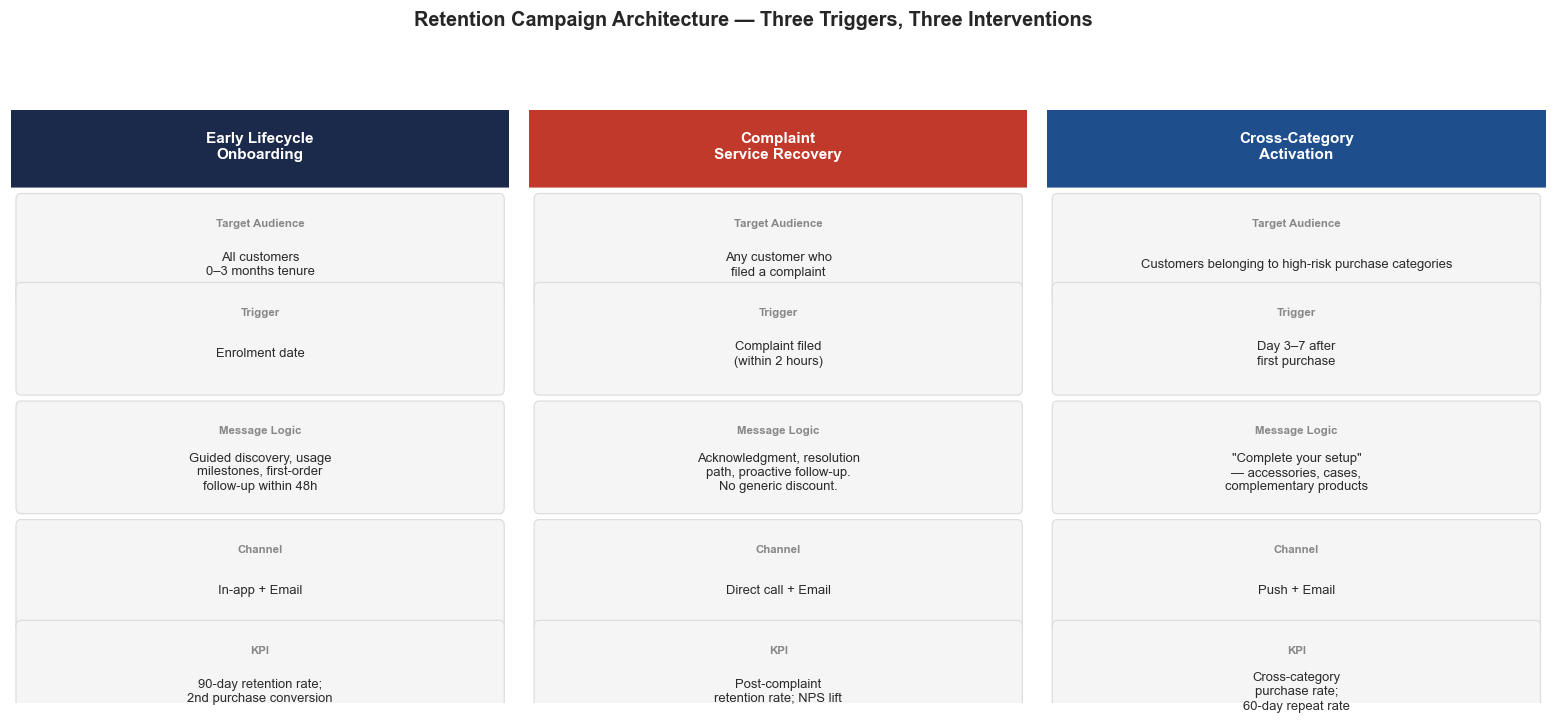

In [37]:
strategy_data = [
    {
        'Campaign'  : 'Early Lifecycle\nOnboarding',
        'Target'    : 'All customers\n0–3 months tenure',
        'Trigger'   : 'Enrolment date',
        'Message'   : 'Guided discovery, usage\nmilestones, first-order\nfollow-up within 48h',
        'Channel'   : 'In-app + Email',
        'KPI'       : '90-day retention rate;\n2nd purchase conversion',
        'Color'     : NAVY_DARK
    },
    {
        'Campaign'  : 'Complaint\nService Recovery',
        'Target'    : 'Any customer who\nfiled a complaint',
        'Trigger'   : 'Complaint filed\n(within 2 hours)',
        'Message'   : 'Acknowledgment, resolution\npath, proactive follow-up.\nNo generic discount.',
        'Channel'   : 'Direct call + Email',
        'KPI'       : 'Post-complaint\nretention rate; NPS lift',
        'Color'     : ACCENT_RED
    },
    {
        'Campaign'  : 'Cross-Category\nActivation',
        'Target'    : 'Customers belonging to high-risk purchase categories',
        'Trigger'   : 'Day 3–7 after\nfirst purchase',
        'Message'   : '"Complete your setup"\n— accessories, cases,\ncomplementary products',
        'Channel'   : 'Push + Email',
        'KPI'       : 'Cross-category\npurchase rate;\n60-day repeat rate',
        'Color'     : NAVY_MID
    },
]

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.subplots_adjust(wspace=0.04)

row_labels = ['Target Audience', 'Trigger', 'Message Logic', 'Channel', 'KPI']
row_heights = [0.82, 0.67, 0.47, 0.27, 0.10]

for ax, seg in zip(axes, strategy_data):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    # Header bar
    ax.add_patch(mpatches.FancyBboxPatch(
        (0, 0.88), 1.0, 0.12,
        boxstyle='round,pad=0.01',
        facecolor=seg['Color'], edgecolor='none'
    ))
    ax.text(0.5, 0.94, seg['Campaign'],
            ha='center', va='center',
            fontsize=10, fontweight='bold', color='white',
            multialignment='center')

    # Content boxes
    contents = [
        seg['Target'], seg['Trigger'],
        seg['Message'], seg['Channel'], seg['KPI']
    ]

    for label, content, y_pos in zip(row_labels, contents, row_heights):
        ax.add_patch(mpatches.FancyBboxPatch(
            (0.02, y_pos - 0.14), 0.96, 0.17,
            boxstyle='round,pad=0.01',
            facecolor='#f5f5f5', edgecolor='#dddddd', linewidth=0.8
        ))
        ax.text(0.5, y_pos - 0.01,
                label,
                ha='center', va='center',
                fontsize=7.5, color='#888888', fontweight='bold')
        ax.text(0.5, y_pos - 0.08,
                content,
                ha='center', va='center',
                fontsize=8.5, color='#2b2b2b',
                multialignment='center')

fig.suptitle('Retention Campaign Architecture — Three Triggers, Three Interventions',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('retention_strategy.png', dpi=150, bbox_inches='tight')
plt.show()

### **4.3 Prioritisation and Budget Logic**

Not all three campaigns warrant equal investment. The model's lift analysis and the EDA risk quantification provide a principled basis for budget allocation.

**Tier 1: Highest ROI: Complaint Service Recovery.** The 66.1% churn rate in the 0–3 month + complaint quadrant defines the highest-risk customer group in the dataset. The intervention cost is low (a direct service contact) relative to the LTV at stake, and the trigger is unambiguous. This campaign should run continuously, fully automated, with a 2-hour SLA from complaint to first contact.

**Tier 2: Highest volume: Early Lifecycle Onboarding.** With 41.9% churn in the first quarter, the onboarding window is where churn risk is most concentrated. This is a systemic intervention rather than a reactive one, it addresses the structural cause of early attrition rather than its symptom. Investment here prevents the Complaint Recovery campaign from being overwhelmed.

**Tier 3: Growth lever: Cross-Category Activation.** Category-based engagement campaigns represent a lower-priority but potentially scalable opportunity. The analysis suggests that purchasing behaviour differs across product categories, and that some customer segments exhibit consistently higher churn rates than others. Personalised post-purchase recommendations may therefore help increase repeat purchasing and long-term engagement, although the causal impact of such interventions would need to be validated experimentally.

### 4.4 Recommended Campaign

Among the three proposed interventions, the Complaint Service Recovery programme should be prioritised as the first campaign to deploy.

The rationale is straightforward: customers who file a complaint exhibit substantially higher churn rates than the rest of the customer base, and the combination of a complaint with low tenure identifies the highest-risk segment observed in the analysis. Unlike broader retention initiatives, the trigger is unambiguous and the intervention can be activated immediately after the complaint is recorded.

The proposed campaign consists of a service recovery workflow initiated within two hours of complaint submission. Customers receive an acknowledgment of the issue, a clear resolution path, and a proactive follow-up once the case has been addressed. The objective is not to provide generic discounts, but to restore trust and prevent customer disengagement at the moment when churn risk is highest.

Campaign success should be evaluated through post-complaint retention rate, churn reduction within the complaint segment, and customer recovery within 60 days of the intervention.

## 5. From Model to Action

This section outlines what it would take to move the XGBoost classifier from an analytical model to an operational retention system.

**Batch scoring and campaign integration.** The most immediate deployment path is a weekly scoring pipeline: the trained model runs on the full active customer base, assigns each customer a churn probability score between 0 and 1, and feeds that score into the CRM. The three campaign pillars defined in Section 4 map directly onto score thresholds. The churn score can be combined with behavioural triggers. Customers with high predicted risk can be prioritised within the onboarding and service-recovery programmes, while complaint events and early-tenure status remain the primary campaign triggers. This transforms the campaign architecture from a manually triggered exercise into a continuously operating system where the model decides who needs attention and when.

**Trigger-based automation.** The complaint recovery campaign has a specific operational requirement that batch scoring alone cannot satisfy: a 2-hour response SLA from complaint filing to first contact. This requires event-driven scoring, when a complaint is logged, the model rescores that customer immediately and, if the predicted churn probability exceeds the threshold, triggers the service recovery workflow without waiting for the next batch run. The infrastructure for this is standard in modern CRM platforms and does not require retraining, only an API endpoint that accepts a customer record and returns a probability score.

**Model monitoring and retraining.** The XGBoost model was trained on a static dataset. Customer behaviour changes, new device categories, shifts in complaint patterns, macroeconomic effects on purchasing frequency, and a model that does not update will gradually misclassify customers it was once accurate on. A quarterly review cycle provides a practical starting point: at each review, the model's predictions from the previous quarter are compared against actual churn outcomes, and if error rates have increased meaningfully, retraining is triggered on the most recent data window. Each retraining cycle also provides an opportunity to evaluate whether the three-feature driver hierarchy identified in Section 3.6 remains stable, or whether new signals have emerged that warrant revisiting the feature set.

## 6. Conclusion

This analysis moved from raw customer records to a deployed-ready churn prediction system in four steps: a rigorous data audit that corrected domain violations and harmonised inconsistent labels; an exploratory phase that identified the structural drivers of churn rather than merely describing their distribution; a modelling phase that compared three algorithms and selected the one best suited for production deployment; and a strategy phase that translated model outputs into a trigger-based retention architecture.

The central finding is that churn in this dataset is not a gradual, uniform process, it is concentrated, predictable, and addressable. Customers in their first three months exhibit substantially higher churn rates than the rest of the customer base, and the combination of early tenure and a filed complaint identifies the highest-risk segment observed in the dataset. These are not statistical tendencies; they are identifiable, triggerable moments in the customer lifecycle where a timely intervention materially changes the outcome. The model's lift analysis quantifies the efficiency gain: by acting on the top 20% of customers ranked by predicted churn probability, the retention team recovers 99.5% of at-risk customers without touching the stable base.

Two structural limitations define the boundaries of what this analysis can and cannot answer. First, the model is a snapshot: it predicts churn probability at the current moment based on historical behavior, but it cannot anticipate how a customer's risk profile will evolve. A customer who is low-risk today may cross the complaint threshold next week; without continuous re-scoring, the model's interventions will always lag the reality. In a production setting, the XGBoost model should be retrained on a monthly cadence and scores updated accordingly. Second, the analysis identifies correlation, not causation. Product-category effects appear predictive, but their causal mechanism cannot be established from the available data. A holdout experiment on category-based post-purchase recommendations would be required before scaling this campaign. A holdout experiment, randomly assigning a subset of high-risk category buyers to the activation campaign and comparing their 60-day retention against a control group, is the correct next step before scaling the campaign budget.

Both limitations point toward the same extension: a dynamic, experiment-driven retention system where the model scores are used not just for targeting, but for continuous learning. Each campaign wave generates labeled outcome data, who churned despite intervention, who stayed without it, that can be fed back into the next model iteration. Over time, this closes the gap between prediction and causation, and between a static classifier and a live retention engine.